# **Quantum gates with Rydberg atoms**

Mariona Montaner Carbó

Treball de Final de Grau Juny 2026

--------------------------------

 In the context of quantum computation with neutral atoms, we study the implementation of quantum gates focusing on
the strong, long-range interactions provided by Rydberg states. First, single-qubit operations are
modelled using Rabi oscillations and Maxwell-Bloch equations, characterizing decoherence and error
sources. Next, we introduce the Rydberg blockade mechanism to simulate conditional quantum
dynamics, specifically implementing a two-qubit controlled-NOT (CNOT) gate. By introducing an
error model accounting for spontaneous emission and pulse fluctuations, we achieve a simulated gate
fidelity of 95.46%, which is then is optimized to 96.15%. Finally, these operations are integrated
into a dense coding circuit to demonstrate a practical quantum communication protocol.

In this notebook the codes and simulations developed during the project can be found.

--------------------------------

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

In [9]:
!pip install qutip

In [10]:
!pip install qiskit
!pip install pylatexenc
!pip install qiskit_aer

-----

## Atomic structure of $^{87}Rb$ [1]

Rubidium is an alkali atom with the ground state electronic configuation of  $^{87} Rb$: $1s^2 2s^2 2p^6 3s^2 3p^6 3d^{10} 4s^2 4p^6 5s^1$.

The valence electron occupies the $5s$ orbital and determines the vast majority of atomic properties since the remaining electrons are coupled to a total angular momentum $J=0$. In an $s$ orbital the electron has an angular momentum $L=0$, therefore, a total angular momentum $J=0\otimes 1/2=1/2$. Thus the ground state of $^{87} Rb$ is the $5^2 S_{1/2}$ fine structure level.

For $s$ orbitals, the wave functions have a significant amplitude at small $r$, therefore, they go penetrate deeply into the nucleus and experience a larger nuclear charge. The inner electrons screen the nuclear charge, so an efective charge needs to be considered. The energy levels not only will depend on $n$ but also on $l$, through the quantum defect $\delta_l$, following the modified Bohr formula:

$$E(n,l)= -\frac{1}{2(n-\delta_l)^2}E_h $$

with $E_h=27.211 $ eV and for the $s$ orbital of the  $^{87}Rb$ , $\delta_l=3.19$ [1]




In [11]:
# Càlcul de l'energia de l'estructura grossa (GHz)


def estructura_grossa(n):
    Eh=27.211386245988
    delta_l=3.19
    C=2.417989e+5 #e/h(10e+9)
    energia_grossa=-C*Eh/(2*(n-delta_l)**2)
    return energia_grossa

estructura_grossa(5)

-1004194.5089824834

#### Fine structure


Since the ground state of $^{87} Rb$ has orbital angular momenutm $L=0$, there is no spin-orbit interaction and therefore no fine structure splitting.

Regarding the Darwin and relativistic mass correction terms, the energy level is not modified, as the quantum defect $\delta_l$ is an experimental parameter that already incorporates these corrections.

#### Hyperfine structure


Hyperfine structure also considers the nuclear total angular momentum $I$, which for the $^{87}$ Rb is $I=3/2$.

The total angular momentum  $\vec{F}=\vec{J}+\vec{I}$ of the ground stat will be $F=1/2 \otimes 3/2 = 1 \oplus 2$ so the ground state splits into 2 hyperfine levels with $F=1$ and $F=2$.

The hyperfine energy correction is given by:

$$\langle \mathcal{H}_{hf} \rangle = A \langle \vec{I}\cdot \vec{J}\rangle=\frac{A}{2} \langle \vec{F}^2-\vec{I}^2-\vec{J}^2\rangle$$

where $A$ is the magnetic dipole constant. For $^{87}Rb$ is  $A=3.4173413$ GHz [2].

This Hamiltonian is diagonal in the coupled basis $|I\,J\,F\, M_F\rangle$  and therefore:

$$\langle \mathcal{H}_{hf} \rangle  = \frac{A}{2}[F(F+1)- I(I+1) - J(J+1)]\hbar^2$$

For $^{87} Rb$ in the ground state:

- $F=1$ $\rightarrow$ $\langle \mathcal{H}_{hf} \rangle^{F=1} = -\frac{5}{4}A$
  
- $F=2$ $\rightarrow$ $\langle \mathcal{H}_{hf} \rangle^{F=2} = \frac{3}{4}A$


The energy diference between the two hyperfine levels is $\Delta E = 2A \approx 6.845$ GHz.

In [12]:
#Càlcul dels nous nivells hiperfins (GHz)

def estructura_hiperfina(n,F, I, J):

    A=3.4173413 #GHz

    energia_grossa=estructura_grossa(n)

    energia_hf=energia_grossa+(A/2.0)*(F*(F+1)-I*(I+1)-J*(J+1))

    return energia_hf


estructura_hiperfina(5,2,1.5,0.5)




-1004191.9459765084

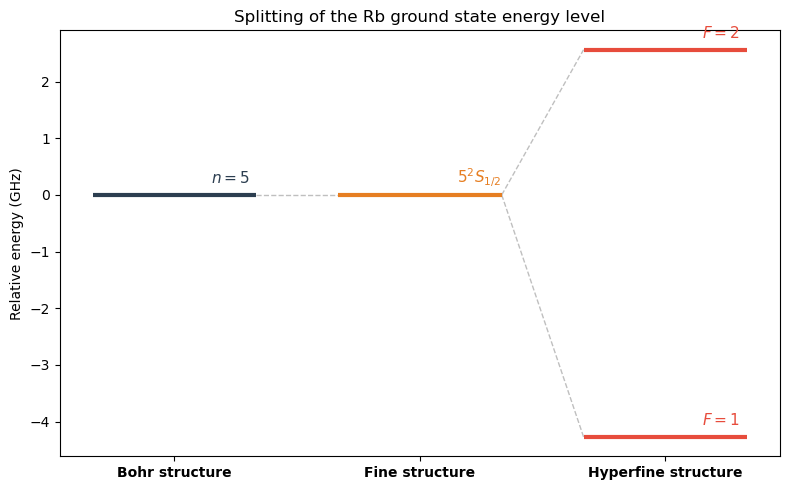

In [13]:
#Representació esquemàtica desdoblament dels nivells

def plot_desdoblament_nivells():
    fig, ax = plt.subplots(figsize=(8, 5))

    # Estructura Grossa: n=5
    n = 5
    E0 = estructura_grossa(n)

   # Estructura Hiperfina: desdoblament amb F=1 i F=2
    E_hf_1 = estructura_hiperfina(5,1, 1.5, 0.5)
    E_hf_2 = estructura_hiperfina(5,2, 1.5, 0.5)

    # Energies relatives
    grossa = [(0, r'$n=5$')]
    fina = [(0, r'$5^2S_{1/2}$')] #Estructura fina: no hi ha desdoblament ja que L=0
    hiperfina = [
        (E_hf_1 - E0, r'$F=1$'),
        (E_hf_2 - E0, r'$F=2$')
    ]

    nivells = [grossa, fina, hiperfina]
    nivells_columna = ['Bohr structure', 'Fine structure', 'Hyperfine structure']
    colors = ['#2c3e50', '#e67e22', '#e74c3c']


    for i, level_group in enumerate(nivells):
        x_start = i * 3
        x_end = x_start + 2

        for energy, txt in level_group:
            ax.hlines(energy, x_start, x_end, colors=colors[i], lw=3)
            ax.text(x_end - 0.55, energy+0.3, txt,
                    va='center', fontsize=11,
                    fontweight='bold', color=colors[i])


    # Línies de connexió
        if i > 0:
            x_prev_end = (i - 1) * 3 + 2
            x_curr_start = x_start

            # Connectem cada nivell de la columna actual amb el de l'anterior
            for energy_actual, _ in level_group:
                energy_previa = nivells[i-1][0][0]

                ax.plot([x_prev_end, x_curr_start], [energy_previa, energy_actual],
                        color='gray', linestyle='--', alpha=0.5, linewidth=1, zorder=1)


    ax.set_title('Splitting of the Rb ground state energy level')
    ax.set_ylabel('Relative energy (GHz)')

    ax.set_xticks([1, 4, 7])
    ax.set_xticklabels(nivells_columna, fontweight='bold')


    plt.tight_layout()
    plt.show()

plot_desdoblament_nivells()

### Interaction with a magnetic field: Zeeman effect

The Zeeman effect produces a splitting of the hyperfine levels in the weak field regime, defined by $\mu_B B \ll A$.

Since $A/2\approx 6.835$ GHz for the ground state of $^{87}Rb$, the weak field condition corresponds approximately to $B \ll 10^3$ G.

If we consider a constat magnetic field applied along the $\hat{z}$ direction:  $\vec{B}=B\hat{z}$

The Hamiltonian that describes the perturbation of the hyperfine energy levels is:

$$\mathcal{H}=g_F \mu_B \vec{F}\cdot \vec{B}=g_F\mu_B B F_z$$

The Landé factor $g_F$ is

$$g_F=\frac{F(F+1)+J(J+1)-I(I+1)}{2F(F+1)}g_J$$

with $g_J \approx 2$.

This Hamiltonian is diagonal in the coupled basis $|I\,J\,F\, M_F\rangle$ and therefore,the Zeeman energy shift is

$$E=g_F \mu_B B M_F$$

where $M_F=-F,...,F$.

Therefore, the hyperfine structure level $F=1$ will split into three Zeeman sublevels corresponding to $M_F=-1,0,1$ with $g_F=-1/2$ and the $F=2$ level will split into five sublevels corresponding to $M_F=-2,-1,0,1,2$  with $g_F=1/2$.

In [14]:
# Càlcul nivells energia Zeeman (GHz)

def nivells_Zeeman(n,F,Mf,gF,B):

    mu_B=1.4e-3 #GHz/G
    energia_hf=estructura_hiperfina(n,F,1.5,0.5)

    energia_zeeman=energia_hf+gF*mu_B*B*Mf

    return energia_zeeman

B= 200 #(G)
nivells_Zeeman(5,1,-1,-1/2,B)

-1004198.6406591084

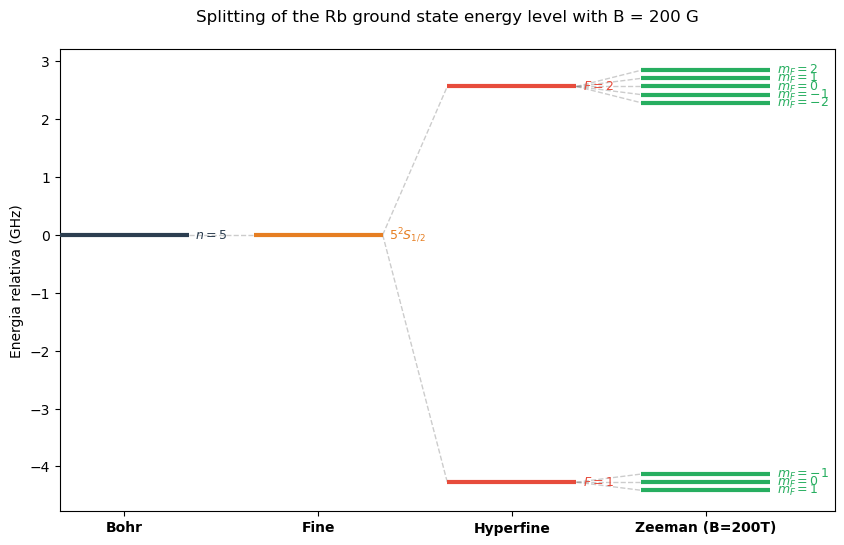

In [15]:
#Representació esquemàtica desdoblament dels nivells amb efecte Zeeman

def plot_desdoblament_zeeman(B):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(10, 6))


    # Estructura Grossa: n=5 (mateixa energia que per estructura fina)
    n = 5
    E0 = estructura_grossa(n)

   # Estructura Hiperfina: desdoblament amb F=1 i F=2
    E_hf_1 = estructura_hiperfina(5,1, 1.5, 0.5)
    E_hf_2 = estructura_hiperfina(5,2, 1.5, 0.5)

    # Constants gF
    gF_F1 = -0.5
    gF_F2 = 0.5

     # Energies relatives
    grossa = [(0, r'$n=5$')]
    fina = [(0, r'$5^2S_{1/2}$')] #Estructura fina: no hi ha desdoblament ja que L=0
    hiperfina = [
        (E_hf_1 - E0, r'$F=1$'),
        (E_hf_2 - E0, r'$F=2$')
    ]

    # Càlcul Zeeman per a cada mF
    zeeman_F1 = [(nivells_Zeeman(5, 1, mf, gF_F1, B) -E0, f'$m_F={mf}$') for mf in [-1, 0, 1]]
    zeeman_F2 = [(nivells_Zeeman(5, 2, mf, gF_F2, B) -E0, f'$m_F={mf}$') for mf in [-2, -1, 0, 1, 2]]

    nivells = [grossa, fina, hiperfina, zeeman_F1 + zeeman_F2]
    nivells_columna = ['Bohr', 'Fine', 'Hyperfine', f'Zeeman (B={B}T)']
    colors = ['#2c3e50', '#e67e22', '#e74c3c', '#27ae60']

    #nivells
    for i, level_group in enumerate(nivells):
        x_start = i * 3
        x_end = x_start + 2

        for energy, txt in level_group:
            ax.hlines(energy, x_start, x_end, colors=colors[i], lw=3, zorder=3)
            ax.text(x_end + 0.1, energy, txt, va='center', fontsize=9, fontweight='bold', color=colors[i])

        # linees de connexió
        if i > 0:
            x_prev_end = (i - 1) * 3 + 2
            x_curr_start = x_start

            for energy_actual, _ in level_group:

                if i == 3:  # Connexió Hiperfina -> Zeeman

                    dist_F1 = abs(energy_actual - (E_hf_1 - E0))
                    dist_F2 = abs(energy_actual - (E_hf_2 - E0))

                    energy_previa = (E_hf_1 - E0) if dist_F1 < dist_F2 else (E_hf_2 - E0)
                else:
                    # Connexió Grossa->Fina i Fina->Hiperfina
                    energy_previa = nivells[i-1][0][0]

                ax.plot([x_prev_end, x_curr_start], [energy_previa, energy_actual],
                        color='gray', linestyle='--', alpha=0.4, linewidth=1, zorder=1)


    ax.set_title(f'Splitting of the Rb ground state energy level with B = {B} G', pad=20)
    ax.set_ylabel('Energia relativa (GHz)')
    ax.set_xticks([1, 4, 7, 10])
    ax.set_xticklabels(nivells_columna, fontweight='bold')

    ax.set_xlim(0,12)


    plt.show()

plot_desdoblament_zeeman(B=200)

----

## Rabi oscillations


Now we want to foucus on te response of an atom when an oscillating electric field is applied. The system will evolve follwing the Scrödinger's equation

$$i \hbar \frac{\partial}{\partial t}|\Psi (t) \rangle =[\mathcal{H}_0+\mathcal{H}_I(t)]|\Psi (t) \rangle$$

where $\mathcal{H}_0$ is the Hamiltonian of the atom that describes the atomic energy levels and $\mathcal{H}_I(t)$ describes the interaction with the oscillating electric field.

We can write the wave function in terms of the basis functions of our atomic system, that is, the eigenstates of the $\mathcal{H}_0$ Hamiltonian $\mathcal{H}_0 |n\rangle=E_n|n\rangle$, as:

$$|\Psi (t)\rangle = \sum_n C_n(t) e^{-iE_n t/\hbar} |n\rangle $$

If we plug it into the Scrödinger's equation:

$$i\hbar \sum_n \left[ \dot{c}_n(t)e^{-iE_nt/\hbar}|n\rangle -\frac{i E_n}{\hbar}C_n(t)e^{-iE_nt/\hbar}|n\rangle \right]=\sum_n \left[ c_n(t)e^{-iE_nt/\hbar} E_n |n\rangle+ c_n(t)e^{-iE_nt/ħ}\mathcal{H}_I |n\rangle \right]$$

Simplifying terms and multiplying for the state $\langle k|$, remembering the orthogonality of eigenstates $\langle k|n\rangle =\delta_{kn}$ we obtain

$$i\hbar \dot{c}_k(t)=\sum_n c_n(t)e^{i\omega_{nk}t} \langle k| \mathcal{H}_I|n \rangle$$

where $\omega_{nk}=\frac{E_n-E_k}{\hbar}$ and the term $\langle k| \mathcal{H}_I|n \rangle$ is the matrix element that denotes how strong the $n$ state is linked to the $k$ state in our system.



### Two-level system [1]

The solution of the previous equation can be easier to find if we consider an atom with two levels: the ground state $|1\rangle$ and the excited state $|2\rangle$ where the difference of energy between the two levels is given by $\hbar \omega_{12}=E_2-E_1$.

If we consider that the time-dependant part of the Hamiltonian $\mathcal{H}_I (t)$ is given by $\mathcal{H}_I (t)= -\hat{d}\cdot \vec{E}$ where $\vec{E}=\vec{\varepsilon}E_0 \cos(\omega t)$ with $\vec{\varepsilon}$ the polarisation vector, $E_0$ the amplitude of the field and $\omega$ the frequency of the field.

In that case, we obtain two diferential equations for the $c_1(t)$ and $c_2(t)$ coefficients, keeping in mind that the diagonal terms $\langle{n}| \vec{d}\cdot y\vec{\varepsilon} |{n}\rangle$=0 because of the smmmetry :

$$i\hbar \dot{c}_1(t)= c_2(t) e^{-i\omega_{12} t}\langle{1}| \vec{d}\cdot \vec{\varepsilon} |{2}\rangle E_0 \cos(\omega t) $$
$$i\hbar \dot{c}_2(t)= c_1(t) e^{-i\omega_{12} t}\langle{2}| \vec{d}\cdot \vec{\varepsilon} |{1}\rangle E_0 \cos(\omega t) $$

If we define $\Omega_0=\frac{\langle{1}| \vec{d}\cdot \vec{\varepsilon} |{2}\rangle E_0}{\hbar}$ as the Rabi frequency and it describes how fast the atom oscillates between the $|1\rangle$ and $|2\rangle $ states. Writing $\cos(\omega t)$ in terms of exponential functions, we can rewrite the equations as

$$ i \dot{c}_1(t) = c_2(t) [e^{i (\omega-\omega_0)t}+e^{-i(\omega+\omega_0)t}]\frac{\Omega_0}{2}$$
$$ i \dot{c}_2(t) = c_1(t) [e^{i (\omega-\omega_0)t}+e^{-i(\omega+\omega_0)t}]\frac{\Omega_0}{2}$$

Where we can define the detuning as $\delta=\omega-\omega_{12}$.

If $\delta$ is small then $\omega \sim \omega_{12}$ the term $\omega + \omega_{12}$ oscillates very fast and therefore at first aporoximation the average value over time is 0 so we can neglect these terms. That's called the rotating wave aproximation which is valid for small $\delta$. In that approximation the equations are

$$ i \dot{c}_1(t) = \frac{\Omega_0}{2} e^{i \delta t}c_2(t)$$
$$ i \dot{c}_2(t) = \frac{\Omega_0}{2} e^{i \delta t}c_1(t)$$

Combining the two equations we obtain

$$\frac{d^2 c_2(t)}{dt^2}+i \delta \frac{dc_2(t)}{dt}+\left(\frac{\Omega_0}{2}\right)^2 c_2(t)=0$$

with the initial condition $c_1(0)=1$ and $c_2(0)=0$ we obtain the amplitude $C_2(t)$ and the probability of finding the atom on the excited state $P_2(t)=|c_2(t)|^2$:

$$c_2(t)=i\frac{\Omega_0}{\Omega}e^{-i\delta t/2} \sin \left(\frac{\Omega t}{2}\right)$$
$$P_2(t)=|c_2(t)|^2 =\frac{\Omega_0^2}{\Omega^2}\sin^2\left(\frac{\Omega t}{2}\right)$$

where $\Omega=\sqrt{\Omega_0^2+\delta^2}$ is the efective Rabi frequency.

#### Resonant case $\delta =0$


If we analize the resonant case where $\omega=\omega_{12}$, the probability becomes:

$$P_2(t)=\sin^2\left(\frac{\Omega_0 t}{2}\right)$$

In that situation there are some special cases:

- **$\pi$-pulse**: Applying a $\Omega_0 \tau = \pi$ pulse into the system will cause a swap in the population of both states, if the system was initially in the $|1\rangle$ state, after the pulse it will be in the $i|2\rangle $ state and similarly if the system is initially in the $|2\rangle$ state.

- **$2\pi$-pulse**: Applying a $\Omega_0 \tau=2\pi$ pules into the system will cause a change of sign in the initial state. If the system was initially in a general $\alpha |1\rangle + \beta |2\rangle$ state after the pulse the state will be $-(\alpha |1\rangle + \beta |2\rangle)$.

- **$\pi/2$-pulse**: Applying a $\Omega_0 \tau=\pi/2$ pulse into the system will bring the system superposition state. If the initial state of the system was $|1\rangle$, after the pulse the system will be in a superposition of both states $\frac{1}{\sqrt{2}}(|1\rangle+i|2\rangle)$.


#### Non resonant case $\delta \neq 0$



For the non resonant case $\delta \neq 0$ we cannot have a probability 1 of our system to be in the excited state $|2\rangle$. The probability of finding the state in the $|2\rangle$ state is maximum when a $ \pi$-pulse is applyed and the value will depend on the $\frac{\Omega_0}{\Omega}$ coefficient.


In [16]:
#Evolution of the probability depending on the detuning and the Rabi frequency

def plot_probability(omega_0, delta):

  t=np.linspace(0,10,1000)

  omega=np.sqrt(omega_0**2+delta**2)

  p2=(omega_0/omega)**2*(np.sin(omega*t/2.0))**2
  p1=1-p2

  plt.figure(figsize=(10,6))

  plt.plot(t,p1, label=f'$P_1(t)$', color='red',lw=2)
  plt.plot(t,p2, label=f'$P_2(t)$', color='royalblue',lw=2)


  plt.title('Probability time evolution', fontsize=14)
  plt.xlabel('t')
  plt.ylabel('Probability')
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.ylim(-0.1, 1.1)
  plt.legend()
  plt.show()

interact(
    plot_probability,
    omega_0=FloatSlider(min=0, max=10, step=0.1, value=4, description='Rabi frequency'),
    delta=FloatSlider(min=0, max=3, step=0.1, value=0, description='Detuning')
);


interactive(children=(FloatSlider(value=4.0, description='Rabi frequency', max=10.0), FloatSlider(value=0.0, d…

### Bloch sphere


The Bloch sphere is a geometric represntation used to visualize the state of a single qubit in a three-dimensional space. While a qubit is a mathematically a unit vector in a two dimensional complex vector space, its obserbale properties can be mapped to points on or inside a unit sphere.

A pure state of a single qubit can be written in a general normalized form as

$$|\Psi \rangle= \cos\left(\frac{\theta}{2}\right)|0\rangle + e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle$$

where $\theta$ and $\phi$ determine a specific point on the surface of the unit sphere.


The poles of the sphere correspond to the elements of the basis (the north pole for $|0\rangle$ and the south for $|1\rangle$) and the equator represents equal superpositions of $|0\rangle$ and $|1\rangle$ such as the states $|+\rangle =(|0\rangle+|1\rangle)/\sqrt{2}$ and $|-\rangle =(|0\rangle-|1\rangle)/\sqrt{2}$.

In this representation, diametrically opposite states on the sphere are mathematically orthogonal.


In the context of Rabi oscillations, the puleses applied to the system can be visuallised using the Bloch sphere.

In the ressonant case ($\delta=0$) the interaction with the external field causes the Bloch vector to rotate around an axis located within the equatorial ($xy$) plane of the sphere.

The different pulses correspond to specific geometric rotations of the state:

- **$\pi$-pulse**: Performs a 180 degree rotation of the Bloch vector. This results in a complete population transfer between the two levels and is the equivalent of a "NOT" gate.

- **$2\pi$-pulse**: Performs a 360 degree rotation, moving the Bloch vector in a "full circle" back to its initial position. With this operations the state acquires a $\pi$ phase shift thus a full $4\pi$ rotation is required to return to the original state with the same phase (identity operation).

- **$\pi/2$-pulse**: Performs a 90 degree rotation of the Bloch vector. This creats an equal superposition of the ground and excited states. For instance, if the initial state is one of the poles of the sphere, after a $\pi/2$ pulse the vector will point into the equator.

For the non resonant case ($\delta \neq0$) the detuing causes the state vector to follow a trajectory that differs from the resonant case.

A we have seen, in the ressonant case, the rotation axis lies in the equatorial plane. When we introduce detuning, the rotation axis tilits away from the equator.

The axis is defined by the vector $\vec{\Omega} = \Omega_0 \hat{e_1} + \delta \hat{e_2}$. The larger the deuning $\delta$ relative to $\Omega_0$ is, the more the axis points towards the poles.

Because the rotation axis $\vec{\Omega}$ is tilted, the Bloch vector does not trace a circle that passes through both poles. Instead it precesses around the tilted axis $\vec{\Omega}$ tracing the surface of a cone.

In [17]:


# Relevant vectors on the Bloch sphere
from qutip import basis, Bloch

zero = basis(2,0)
one = basis(2,1)

def bloch_plot(theta,phi):
  plus = (zero + one).unit()
  minus = (zero - one).unit()
  psi = np.cos(theta/2)*zero + np.exp(1j*phi)*np.sin(theta/2)*one
  psi = psi.unit()

  b = Bloch()
  b.add_states([zero, one, plus, minus, psi])
  b.vector_color = ['black','black','blue','blue','red']

  b.zlabel = ['|1⟩','|0⟩']
  b.xlabel = ['|−⟩','|+⟩']

  b.show()

interact(
    bloch_plot,
    theta=FloatSlider(min=0, max=np.pi*2, step=0.05, value=0),
    phi=FloatSlider(min=0, max=np.pi*2, step=0.05, value=0),
)

interactive(children=(FloatSlider(value=0.0, description='theta', max=6.283185307179586, step=0.05), FloatSlid…

<function __main__.bloch_plot(theta, phi)>

#### Interaction with the environment


So far, we have considered the system to be isolated, meaning it evolves coherently according to periodic Rabi oscillations. When the system interacts with the environment, spontaneous emission and decoeherence processes occur, causing the oscillations to dampen.

This damping is characterized by the parameters $T_1$ and $T_2$

$T_1$ **Longitudinal relaxation time**

It's the characteristic time for the decay of the excited state population towards the ground state. It is caused by the loss of energy of the system to the environment, for example, through spontaneous emission.

$T_2$ **Transverse relaxation time**

Characterises the time at which a quantum state loses its coherence. Describes the loss of the phase between two states in superposition.

In the density matrix formalism, $T_2$ describes the rate at which the elements outside the diagonal decay toward zero, typically following an exponential factor of $e^{-t/T_2}$

On the Bloch sphere, the loss of phase information, causes the sphere to shrink toward the z-axis and transform into an ellipsoid.





#### Experimental values of $T_1$ and $T_2$


If we consdier the transition $D_2$($780$ nm), which is between the states $5^2P_{3/2}\rightarrow 5^2S_{1/2}$, we can obtain the decay rate because of the spontaneous emission by[2]:


$$\Gamma_{5P\rightarrow 5S}=\frac{\omega_{5p\rightarrow 5s}^3}{3\pi \varepsilon_0 \hbar c^3}\frac{2J+1}{2J'+1}|\langle J||e\vec{r}||J'\rangle|^2$$

where $J=1/2$ and $J'=3/2$, $\omega_{5p\rightarrow 5s}=2\pi \cdot 384.230484$ THz and $\langle J||e\vec{r}||J'\rangle=4.227\,ea_0$. Therefore, for the transition $D_2$, the decay rate is $\Gamma=2\pi \cdot 6.065$ MHz. The lifetime, and consequently $T_1$, is given by $\tau=\Gamma^{-1} =26.24$ ns.

We can also compute the value of the Rabi frequency for a given laser intensity, in the ressonant case, using
$$\Omega=\Gamma \sqrt{\frac{I}{2I_{sat}(\omega)}}$$

where $I_{sat}$ is the saturation intensity and represents the intensity in which the dispersion cross-section of an atom is reduced to the half of its maximum inicial value. This instensity is given by $I_{sat}=\frac{\pi hc \Gamma}{3\lambda^3}$ which for the $D_2$ transition has a value of $I_{sat}\approx 1.67$ mW/cm$^2$.

The intensity of a gaussian beam is given by

$$I(r,z)=I_0 \left(\frac{\omega_0}{\omega(z)}\right)^2 \exp \left(-\frac{2r^2}{w(z)^2}\right)$$

where $I_0$ is the intensity at the center of the beam at its waist and is given by

$$I_0=\frac{2P_0}{\pi \omega_0^2}$$

with $\omega_0$ the beam waist and $P_0$ i sthe total power of the beam. For a beam waist $\omega_0=0.5$ mm and a power $P_0=50$ mW the intensity at the center of the beam is $I_0\approx 12.732$ W/cm$^2$. Taking that value as the intensity of the laser, the value of the Rabi frequency will be $\Omega\approx 2\pi \cdot 374.46$ MHz.





-----



## Maxwell-Bloch Equations

Maxwell-Bloch equations (or optical Bloch equations) describe the temporal evolution of a two-level system that interacts with an electromagnetic field.

To describe a system that is in contact with the environment, we can use the density operator ($\rho$).

$$\rho=\sum_i p_i |\psi_i\rangle\langle \psi_i|$$

For a two-level system, it is a $2\times2$ hermitic matrix where the diagaonal terms $\rho_{gg}$ and $\rho_{ee}$ correspond to the populations of the ground state and the excited state, respectively. The off-diagonal terms, $\rho_{ge}$ and $\rho_{eg}$, represent de coherence of the system, they describe how well is  defined the phase between the two states.

Given the normalization of the states, $Tr(\rho)=1$.

We can diferentiate between pure states, where the system can be described with only one state vector $|\psi\rangle$ and sits in the surface of the Bloch sphere, and mixed states, where the system is described as an statistic ensble of different pure states $|\psi_i\rangle$ with probability $p_i$.

For pure states $Tr(\rho^2)=1$ whereas for mixed states $Tr(\rho^2)<1$.

Now we want to derve tje time evolution of the components of the density matrix. Assuming a pure state, the density matrix will be given by

$$\rho=\begin{pmatrix}
\rho_{gg}&\rho_{ge} \\
\rho_{eg}&\rho_{ee}
\end{pmatrix}=\begin{pmatrix}
c_g c_g^*&c_e c_g^*\\
c_e^*c_g&c_e^*c_e
\end{pmatrix}$$


The time derivative of a component of the matrix will be

$$\frac{d}{dt}\rho_{gg}=\frac{d}{dt}(c_g c_g^*)=\dot{c}_g c_g^* + c_g \dot{c_g}^*$$

and remebering the time derivatives for $c_g$ and $c_e$ obtained in the context of Rabi oscillations

$$\dot{c}_g(t)=i\frac{\Omega_0}{2}e^{i\delta t}c_2(t)$$

$$\dot{c}_e(t)=i\frac{\Omega_0}{2}e^{-i\delta t}c_1(t)$$

we obtain

$$\frac{d}{dt}\rho_{gg}=i\frac{\Omega_0}{2}(e^{i\delta t}\rho_{eg}-e^{-i\delta t}\rho_{ge})$$

That if we do the transformation to the rotating frame of light $\tilde{\rho}_{ge}=e^{-i\delta t}\rho_{ge}$ and $\tilde{\rho}_{eg}=e^{i\delta t}\rho_{eg}$ we obtain

$$\frac{d}{dt}\rho_{gg}=\gamma\rho_{ee}+i\frac{\Omega_0}{2}(\tilde{\rho}_{eg}-\tilde{\rho}_{ge})$$

Doing the same thing for the other components and remebering that the density matrix is hermitian, so $\tilde{\rho}_{ge}=\tilde{\rho}_{eg}^*$ we obtain three coupled diferential equations

$$\frac{d}{dt}\rho_{gg}=\gamma\rho_{ee}+i\frac{\Omega_0}{2}(\tilde{\rho}_{eg}-\tilde{\rho}_{ge})$$
$$\frac{d}{dt}\rho_{ee}=-\gamma \rho_{ee}+i\frac{\Omega_0}{2}(\tilde{\rho}_{ge}-\tilde{\rho}_{eg})$$
$$ \frac{d}{dt}\tilde{\rho}_{ge}=-\left( \frac{\gamma}{2}+i\delta\right) \tilde{\rho}_{ge}+i\frac{\Omega_0}{2}(\rho_{ee}-\rho_{gg})$$

Using that $\rho_{gg}+\rho_{ee}=1$ and defining $w=\rho_{ee}-\rho_{gg}$ we can reduce the system to two equations

$$\frac{d}{dt}w=-\gamma (w+1)-i\Omega_0(\tilde{\rho}_{eg}-\tilde{\rho}_{ge})$$
$$ \frac{d}{dt}\tilde{\rho}_{ge}=-\left( \frac{\gamma}{2}+i\delta\right) \tilde{\rho}_{ge}+i\frac{\Omega_0}{2}(\rho_{ee}-\rho_{gg})$$

For solving this equations numerically we separate the components of the density matrix into its real and imaginary parts

$$\tilde{\rho}_{ge}=x+iy; \hspace{2cm} \rho_{eg}=x-iy$$

so the equations that need to be solved become:

$$\frac{dx}{dt}=-\frac{\gamma}{2}-\delta y$$
$$\frac{dy}{dt}=-\frac{\gamma}{2}y+ \delta x-\frac{\Omega_0}{2}w$$
$$\frac{dw}{dt}=-\gamma(w+1)-2\Omega_0 y$$



The following code solves numerically these equations and gives the time evolution of the population of the ground and excited states over time.

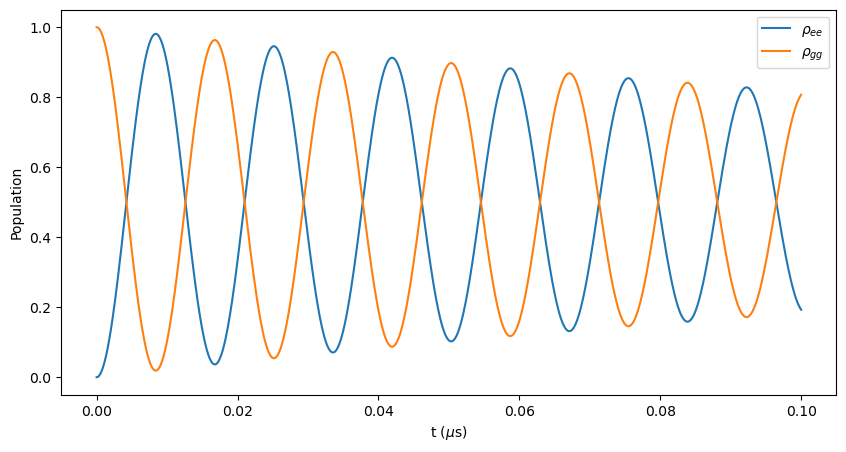

In [19]:
from scipy.integrate import solve_ivp

gamma = 6.065 # decay rate (MHz)
delta = 4 #110.0 # detuning (MHz)
Omega0 = 374.46 # Rabi frequency (MHz)

def bloch_equations(t, y):

    w = y[0]
    x = y[1]
    y_im = y[2]

    dw_dt = -gamma*(w+1) - 2*Omega0*y_im
    dx_dt = -(gamma/2)*x + delta*y_im
    dy_dt = -(gamma/2)*y_im - delta*x + (Omega0/2)*w

    return [dw_dt, dx_dt, dy_dt]


# Initial conditions: the system is initially in the ground state
w0 = -1        # rho_ee - rho_gg = -1
x0 = 0.0
y0 = 0.0

initial_state = [w0, x0, y0]


#interval de temps
t_start = 0
t_end = 0.1

# punts on guardem la solució
t_points = np.linspace(t_start, t_end, 1000)


# integració numèrica
# Runge Kutta adaptatiu
solution = solve_ivp(bloch_equations,[t_start, t_end], initial_state,method='RK45',t_eval=t_points)

t = solution.t

w = solution.y[0]
x = solution.y[1]
y = solution.y[2]


# construïm les solucions

rho_ee = (w + 1)/2
rho_gg = (1 - w)/2
#rho_ge=x+1j*y_im
#rho_eg=x-1j*y_im

#representació gràfica
plt.figure(figsize=(10,5))

plt.plot(t, rho_ee, label=r'$\rho_{ee}$')
plt.plot(t, rho_gg, label=r'$\rho_{gg}$')

plt.xlabel(r't ($\mu$s)')
plt.ylabel("Population")


plt.legend()
plt.show()

In the following simulations we aim to solve the Maxwell-Bloch equations considering that the system is not under a constant frequency excitation.

To do so we first consider equally-spaced variations of a central Rabi frequency and we average over all the different frequencies. And we also try to find the transverse relaxation time $T_2$.

In [ ]:
# Rabi oscillations averaged over different Rabi frequencies

from scipy.optimize import curve_fit

gamma = 6.065   # decay rate (MHz)
delta = 1.2       # detuning (MHz)
Omega0_central = 374.46  # Rabi frequency central (MHz)

#variació de rabi frequency
num_simulacions = 100

omega_values = np.linspace(Omega0_central * 0.9, Omega0_central * 1.1, num_simulacions) #variació d'un 10% respecte el valor central

def bloch_equations(t, y, Omega0): # equacions de Bloch
    w, x, y_im = y
    dw_dt = -gamma*(w+1) - 2*Omega0*y_im
    dx_dt = -(gamma/2)*x + delta*y_im
    dy_dt = -(gamma/2)*y_im - delta*x + (Omega0/2)*w
    return [dw_dt, dx_dt, dy_dt]

# condicions inicials
initial_state = [-1, 0.0, 0.0]
t_start, t_end = 0, 0.1
t_points = np.linspace(t_start, t_end, 1000)

all_rho_ee = np.zeros((num_simulacions, len(t_points))) # matriu per guardar els resultats de rho_ee de cada simulació


for i, Omega in enumerate(omega_values): #solucions de les equacions de Bloch

    sol = solve_ivp(
        bloch_equations,
        [t_start, t_end],
        initial_state,
        args=(Omega,),
        method='RK45',
        t_eval=t_points
    )
    # rho_ee per aquesta Omega específica
    all_rho_ee[i, :] = (sol.y[0] + 1) / 2


rho_ee_mean = np.mean(all_rho_ee, axis=0) # mitjana temporal


#fit del decaiment

def rabi_decay(t,A,T,Omega_eff,phi,C):
  return A*np.exp(-t/T)*np.sin(Omega_eff*t+phi)+C

#parametres inicials
A0=0.5
T0=0.05
Omega0_ini=Omega0_central
phi0=0.0
C0=0.0

p0=[A0, T0, Omega0_ini, phi0, C0]

params,_=curve_fit(rabi_decay,t_points, rho_ee_mean,p0=p0) #optimització del fit

A_fit,T_fit,Omega_fit, phi_fit, C_fit = params

rho_fit=rabi_decay(t_points,*params)



plt.figure(figsize=(10, 6))
plt.plot(t_points, rho_fit, '--', color='blue',
         label=f'Fit $T_2$={T_fit:.4f} $\\mu$s')
plt.legend()


for i in range(num_simulacions):
    plt.plot(t_points, all_rho_ee[i, :], color='gray', alpha=0.2, lw=1)


plt.plot(t_points, rho_ee_mean, color='red', linewidth=2)

plt.xlabel(r't ($\mu$s)')
plt.ylabel("Population $\\rho_{ee}$")
plt.grid(True, linestyle='--', alpha=0.7)

print(f"Fit: rho_ee(t) = {A_fit:.4f} * exp(-t/{T_fit:.4f}) sin({Omega_fit:.4f}  t + {phi_fit:.4f}) + {C_fit:.4f}")


#plt.savefig("maxwell_bloch_t_petites.png", dpi=300, bbox_inches="tight")
#files.download("maxwell_bloch_t_petites.png")
plt.show()



Another aproach we can consider is instead of taking equally-spaced Rabi frequencies, taking random values that follow a certain probability distribution. In the following example we've considered a gaussian distribution centered at a rabi frequency $\Omega\approx 2\pi \cdot 374.46$MHz

In [ ]:
# Rabi oscillations averaged over different Rabi frequencies that follow a gaussian distribution

from scipy.optimize import curve_fit

gamma = 6.065   # decay rate (MHz)
delta = 1.2       # detuning (MHz)
Omega0_central = 374.46  # Rabi frequency central (MHz)

#variació de rabi frequency
num_simulacions = 1000

sigma = 0.05 * Omega0_central  # desviació estàndard
omega_values = np.random.normal(Omega0_central, sigma, num_simulacions)

def bloch_equations(t, y, Omega0): # equacions de Bloch
    w, x, y_im = y
    dw_dt = -gamma*(w+1) - 2*Omega0*y_im
    dx_dt = -(gamma/2)*x + delta*y_im
    dy_dt = -(gamma/2)*y_im - delta*x + (Omega0/2)*w
    return [dw_dt, dx_dt, dy_dt]

# condicions inicials
initial_state = [-1, 0.0, 0.0]
t_start, t_end = 0, 0.5
t_points = np.linspace(t_start, t_end, 1000)

all_rho_ee = np.zeros((num_simulacions, len(t_points))) # matriu per guardar els resultats de rho_ee de cada simulació


for i, Omega in enumerate(omega_values): #solucions de les equacions de Bloch

    sol = solve_ivp(
        bloch_equations,
        [t_start, t_end],
        initial_state,
        args=(Omega,),
        method='RK45',
        t_eval=t_points
    )
    # rho_ee per aquesta Omega específica
    all_rho_ee[i, :] = (sol.y[0] + 1) / 2


rho_ee_mean = np.mean(all_rho_ee, axis=0) # mitjana temporal


#fit del decaiment

def rabi_decay(t,A,T,Omega_eff,phi,C):
  return A*np.exp(-t/T)*np.sin(Omega_eff*t+phi)+C

#parametres inicials
A0=0.5
T0=0.05
Omega0_ini=Omega0_central
phi0=0.0
C0=0.0

p0=[A0, T0, Omega0_ini, phi0, C0]

params,_=curve_fit(rabi_decay,t_points, rho_ee_mean,p0=p0) #optimització del fit

A_fit,T_fit,Omega_fit, phi_fit, C_fit = params

rho_fit=rabi_decay(t_points,*params)



plt.figure(figsize=(10, 6))



for i in range(num_simulacions):
    plt.plot(t_points, all_rho_ee[i, :], color='gray', alpha=0.2, lw=1)


plt.plot(t_points, rho_ee_mean, color='red', linewidth=3)

plt.plot(t_points, rho_fit, '--', color='blue',
         label=f'Fit $T_2$={T_fit:.4f} $\\mu$s')
plt.legend()

plt.xlabel(r't ($\mu$s)')
plt.ylabel("Population $\\rho_{ee}$")
plt.grid(True, linestyle='--', alpha=0.3)

print(f"Fit: rho_ee(t) = {A_fit:.4f} * exp(-t/{T_fit:.4f}) sin({Omega_fit:.4f}  t + {phi_fit:.4f}) + {C_fit:.4f}")


#histograma de la distribució
plt.figure()
plt.hist(omega_values, bins=20, density=False)
plt.xlabel(r'$\Omega$ (MHz)')
plt.ylabel('Counts')
plt.title('Rabi frequency distribution')
plt.show()

#plt.savefig("maxwell_bloch_t_petites.png", dpi=300, bbox_inches="tight")
#files.download("maxwell_bloch_t_petites.png")
plt.show()


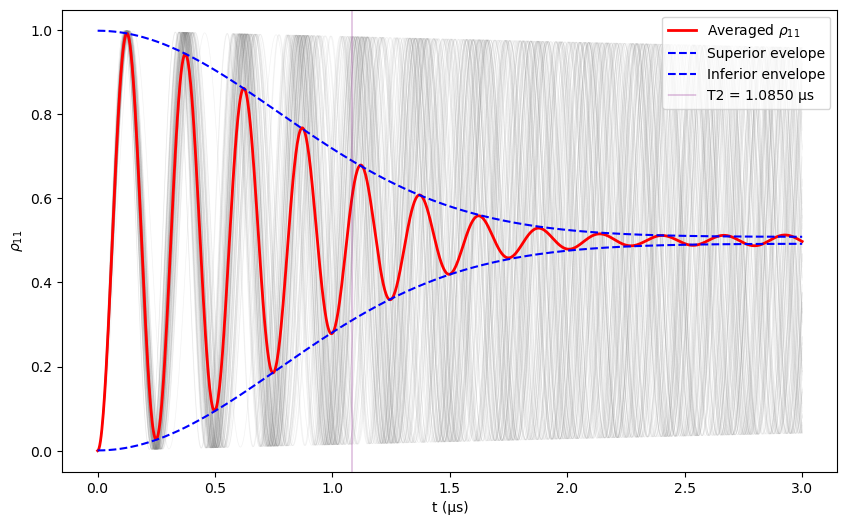

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# Paràmetres
gamma = 1./26.
delta = 0.2
Omega0_central = 2.0*np.pi*4
num_simulacions = 1000
sigma = 0.05 * Omega0_central
omega_values = np.random.normal(Omega0_central, sigma, num_simulacions)

def bloch_equations(t, y, Omega0):
    w, x, y_im = y
    dw_dt = -gamma*(w+1) - 2*Omega0*y_im
    dx_dt = -(gamma/2)*x + delta*y_im
    dy_dt = -(gamma/2)*y_im - delta*x + (Omega0/2)*w
    return [dw_dt, dx_dt, dy_dt]

initial_state = [-1, 0.0, 0.0]
t_start, t_end = 0, 3
t_points = np.linspace(t_start, t_end, 1000)
all_rho_ee = np.zeros((num_simulacions, len(t_points)))

for i, Omega in enumerate(omega_values):
    sol = solve_ivp(bloch_equations, [t_start, t_end], initial_state,
                    args=(Omega,), method='RK45', t_eval=t_points)
    all_rho_ee[i, :] = (sol.y[0] + 1) / 2

rho_ee_mean = np.mean(all_rho_ee, axis=0)

# Detecció de pics
peaks, _ = find_peaks(rho_ee_mean, prominence=0.0001)
min_peaks, _ = find_peaks(-rho_ee_mean, prominence=0.0001)

# Inclusió del punt incial per l'envolvent inferior
t_min_fit = np.insert(t_points[min_peaks], 0, t_points[0])
rho_min_fit = np.insert(rho_ee_mean[min_peaks], 0, rho_ee_mean[0])

# Funcions ajustades
def decay_up(t, A, T2, C):
    return A * np.exp(-t**2/ T2**2) + C
def decay_down(t, A, T2, C):
    return C - A * np.exp(-t**2 / T2**2)

bounds = ([0, 0, 0], [1, np.inf, 1])

# Ajustos
popt_max, _ = curve_fit(decay_up, t_points[peaks], rho_ee_mean[peaks], p0=[0.5, 0.05, 0.5], bounds=bounds)
popt_min, _ = curve_fit(decay_down, t_min_fit, rho_min_fit, p0=[0.5, 0.05, 0.0], bounds=bounds)


t_fit_full = np.linspace(t_start, t_end, 500)
env_max = decay_up(t_fit_full, *popt_max)
env_min = decay_down(t_fit_full, *popt_min)


plt.figure(figsize=(10, 6))
for i in range(min(num_simulacions, 100)):
    plt.plot(t_points, all_rho_ee[i, :], color='gray', alpha=0.1, lw=0.5)

plt.plot(t_points, rho_ee_mean, 'r', lw=2, label='Averaged $\\rho_{11}$')
plt.plot(t_fit_full, env_max, 'b--', label='Superior evelope')
plt.plot(t_fit_full, env_min, 'b--', label='Inferior envelope')


plt.axvline(popt_max[1], color='purple', ls='-', lw=0.3, label=f'T2 = {popt_max[1]:.4f} μs')
plt.xlabel('t (μs)')
plt.ylabel('$\\rho_{11}$')
plt.legend(loc='upper right')


#histograma
#plt.figure()
#plt.hist(omega_values, bins=20)
#plt.xlabel(r'$\Omega$ (MHz)')
#plt.ylabel('Counts')
#plt.title('Rabi frequency distribution')

plt.savefig('rabi_oscillations.pdf')
plt.show()

---

## Ramsey Oscillations (Ramsey Fringes)

Ramsey oscillations are a quantum interference effect observed in a two-level system when it is driven by two radiation pulses separated in time.  


###Procedure

A Ramsey experiment consists of three main steps:

1. **Preparation of a superposition:**  
   A first resonant $\pi/2$ pulse is applied, placing the system in a coherent superposition of the two states.  
   (On the Bloch sphere, this corresponds to moving the state to the equator.)

2. **Free evolution:**  
   The system evolves freely for a time $T$.  
   If there is a detuning $\delta$ between the driving field and the atomic transition, the system accumulates a relative phase:  
   
   $$\phi = \delta T$$

3. **Second pulse and measurement:**  
   A second $\pi/2$ pulse is applied, mixing the states again.  
   The final probability of finding the atom in the excited state depends on the accumulated phase.




**Interference pattern:**  
  By varying the detuning or the time between pulses, the transition probability oscillates as:  
  
  $$P \sim \cos^2(\delta T / 2)$$  

**Measuring decoherence (T₂):**  
  The decay of the oscillation amplitude gives the coherence time $T_2$.  
  Loss of coherence reduces the contrast of the fringes.

- **Spin-echo ($T_2$ measurement):**  
  The spin echo technique, reverses dephasing in inhomogeneous ensembles to recover coherence. The sequence works as follows:

  - Initial $\pi/2$ pulse that creates a coherent superposition, moving the state vectors to the equator of the Bloch sphere.
  - Free evolution (t=T/2). Due to system inhomogeneities (such as different detunings for different atoms) the Bloch vector spreads out along the equator.
  - Inversion $\pi$ pulse. flips the vectors 180º around the equator.
  -Free evolution (t=T/2).This makes that the vectors that where "fast" are now "slow" and the other way
  -The phases are recovered and the vector is aligned again.
The remaining decay is exponential and corresponds to the real $T_2$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# --- Paràmetres Físics ---
gamma = 1.0/51.0
Omega0 = 2.0*np.pi*2.0
sigma_delta = 2.0*np.pi*0.0435
num_atoms = 100


delta_central = 2 * np.pi * 1.0  # Detuning per generar els fringes
delta_doppler = np.random.normal(0.0, sigma_delta, num_atoms) # variació gaussiana

def bloch_equations(t, y, Omega, delta):
    w, x, y_im = y
    dw_dt = -gamma*(w+1) - 2*Omega*y_im
    dx_dt = -(gamma/2)*x + delta*y_im
    dy_dt = -(gamma/2)*y_im - delta*x + (Omega/2)*w
    return [dw_dt, dx_dt, dy_dt]

t_pi2 = np.pi / (2 * Omega0)
t_pi = np.pi / Omega0

T_max = 8.0
T_points = np.linspace(0, T_max, 300)

rho_ee_ensemble_ramsey = np.zeros((num_atoms, len(T_points)))
rho_ee_ensemble_echo = np.zeros((num_atoms, len(T_points)))


for i, d_noise in enumerate(delta_doppler):

    #  pols pi/2
    sol1 = solve_ivp(bloch_equations, [0, t_pi2], [-1, 0, 0], args=(Omega0, d_noise))
    y_after_pi2 = sol1.y[:, -1]

    # Evolució lliure Ramsey
    sol_dark_ramsey = solve_ivp(bloch_equations, [0, T_max], y_after_pi2, args=(0, d_noise + delta_central), t_eval=T_points)

    for j, T in enumerate(T_points):
        # RAMSEY
        # pols pi/2 ressonant
        sol2_ramsey = solve_ivp(bloch_equations, [0, t_pi2], sol_dark_ramsey.y[:, j], args=(Omega0, d_noise))
        rho_ee_ensemble_ramsey[i, j] = (sol2_ramsey.y[0, -1] + 1) / 2

        # SPIN-ECHO
        if T == 0:
            sol_pi = solve_ivp(bloch_equations, [0, t_pi], y_after_pi2, args=(Omega0, d_noise))
            sol_final_echo = solve_ivp(bloch_equations, [0, t_pi2], sol_pi.y[:, -1], args=(-Omega0, d_noise))
        else:
            # Espera T/2
            sol_w1 = solve_ivp(bloch_equations, [0, T/2], y_after_pi2, args=(0, d_noise + delta_central))

            # Pols Pi
            sol_pi = solve_ivp(bloch_equations, [0, t_pi], sol_w1.y[:, -1], args=(Omega0, d_noise))

            # Espera T/2
            sol_w2 = solve_ivp(bloch_equations, [0, T/2], sol_pi.y[:, -1], args=(0, d_noise + delta_central))

            # Pols -pi/2
            sol_final_echo = solve_ivp(bloch_equations, [0, t_pi2], sol_w2.y[:, -1], args=(-Omega0, d_noise))

        rho_ee_ensemble_echo[i, j] = (sol_final_echo.y[0, -1] + 1) / 2

rho_ee_mean_ramsey = np.mean(rho_ee_ensemble_ramsey, axis=0)
rho_ee_mean_echo = np.mean(rho_ee_ensemble_echo, axis=0)

#fits
def decay_gauss(t, A, T2_star, C):
    return A * np.exp(-(t**2) / (T2_star**2)) + C

def decay_exp(t, A, T2, C):
    return A * np.exp(-t / T2) + C

t_fit = np.linspace(0, T_max, 500)

try:
    peaks, _ = find_peaks(rho_ee_mean_ramsey, prominence=0.005)
    popt_ramsey, _ = curve_fit(decay_gauss, T_points[peaks], rho_ee_mean_ramsey[peaks], p0=[0.5, 4.5, 0.5])
    envelope_ramsey = decay_gauss(t_fit, *popt_ramsey)
    t2_star_label = f' Gaussian fit ($T_2^*$ = {popt_ramsey[1]:.2f} $\mu$s)'
except Exception as e:
    envelope_ramsey = np.zeros_like(t_fit)
    t2_star_label = "Error adjusting the gaussian fit"

try:
    popt_echo, _ = curve_fit(decay_exp, T_points, rho_ee_mean_echo, p0=[0.5, 32.0, 0.5], maxfev=5000)
    envelope_echo = decay_exp(t_fit, *popt_echo)
    t2_label = f'Exponential fit ($T_2$ = {popt_echo[1]:.2f} $\mu$s)'
except Exception as e:
    envelope_echo = np.zeros_like(t_fit)


KeyboardInterrupt: 

-------------------------------

## Quantum gates

Quantum gates are the basic components of quantum circuits, analogous to logic gates in classical compuation. Unilke classical gates, quantum gates implement linear and reversible transformations on quantum states in a complex Hilbert space.

The matrices that describe quantum gates must satisfy unitary evolution and linearity  

 $$U^\dagger U= U U^\dagger=I$$

 This property ensures that evolution is always unitary under the action of any hamiltonian (excepting the case where a measure is made). This implies that all quantum gates are reversible. The uniatriety of the dynamics implies reversibility, as all unitary transformations have an inverse (not the other way around).

Unitarity also imposes that a quantum state cannot be copied as unitary evoultion must conserve the scalar proudct of two states. Suppose we want our colonation process to do an unitary evolution such as:

$$|\phi \rangle \otimes |C\rangle \rightarrow |\phi\rangle \otimes \phi \rangle $$

where $|C\rangle$ corresponds to an auxiliar state. This proces must work with an arbitrary $|\psi\rangle$ state and therefore

$$|\psi \rangle \otimes |C\rangle \rightarrow |\psi\rangle \otimes \psi \rangle $$

for any $\psi\rangle$ state. As temporal evolution must be unitary, the scalar product must be conserved

$$\langle \phi |\psi \rangle = \langle \phi | \psi \rangle \langle \phi | \psi \rangle$$

and this equality can only be satisfied if $\langle \phi | \psi \rangle=0$ or $|\langle \phi | \psi \rangle|=1$ so if the scalar product of two normalized states is 1, they are the same state besides a phase. Terefore our initial suposition that the process could clone any state is wrong. If it could clone a satate, then it could only clone states that are orthogonal to the first one or the same as the first one thus it wouldn't be any state.



#### Single-qubit gates

Single qubit gates are represented by $2\times 2$ unitary matrices. They can be represented as rotations in the Bloch sphere. For example we can think of a gate which brings the $|0\rangle$ state to the $|1\rangle$ state and viceversa. As the quantum gate must be linear

$$\alpha |0\rangle + \beta |1\rangle \rightarrow \alpha |1\rangle + \beta |0\rangle$$

therefore in the $\{ |0\rangle |1\rangle \}$ basis it can be written as

$$X \equiv \begin{pmatrix}
0&1 \\
1&0
\end{pmatrix}$$

that is commonly called Pauli-$X$ gate and corresponds to a $\pi$ rotation in the Bloch sphere.

Other commonly used gates are the Pauli-$Y$ and Pauli-$Z$:

$$Y \equiv \begin{pmatrix}
0&-i \\
i&0
\end{pmatrix} \hspace{1cm} Z \equiv \begin{pmatrix}
1&0 \\
0&-1
\end{pmatrix}$$

Another interesting gate is the Haddamard gate $H$ that brings the state $|0\rangle$ to an orthonormal state $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$ and the state $|1\rangle$ to $|-\rangle = (|0\rangle - |1\rangle)/\sqrt{2}$.

$$ H \equiv \frac{1}{\sqrt{2}} \begin{pmatrix}
1&1 \\
1&-1
\end{pmatrix} $$


In the Bloch sphere corresponds to a $\pi$ rotation around the $x$-axis followed by a $-\pi/2$ rotation around the $y$-axis.

#### Two-qubit gates

Two-qubit gates are represented by $4\times 4$ unitary matrices.

While single-qubit gates correspond to rotations in the Bloch sphere, two-qubit gates can create entanglement, a phenomena which has no classical analogy.

One of the most common two-qubit gate is the Controlled-NOT (CNOT) gate. It is applyed to two qubits: one control qubit and one target qubit. It flips the target qubit if and only if the contol qubit is in the sate $|1\rangle$.

The matrix representation in the computational basis $\{|00\rangle, |01\rangle, |10\rangle , |11\rangle \}$ is:

$$U_{CNOT}= \begin{pmatrix}
1&0&0&0 \\
0&1&0&0 \\
0&0&0&1\\
0&0&1&0
\end{pmatrix}$$

This gate is unitary and reversible and satisfies

$$U_{CNOT}^2=I$$

Two-qubit gates can generate entanglement. For example applying a Hadamard gate on the first qubit ($H\otimes I$) of the state $|00\rangle$ followed by a CNOT gate produces the entagnled state $\frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$.

Another important two-qubit gate is the cotrolled-phase gate, that adds a phase-1 to the state $|11\rangle$ and is represented, in the computational basis, with the matrix:

$$U_{CZ}= \begin{pmatrix}
1&0&0&0 \\
0&1&0&0 \\
0&0&1&0\\
0&0&0&-1
\end{pmatrix}$$




------------------------

## Rydberg interactions

Rydberg atoms are atoms that have an electron excited to a state with a large principle quantum number $n$. For that, they are highly sensible to external fields and interactions.

They have a radius that scales with $n^2$ and a polarizability that scales with $n^7$. This leads to strong long-range interactions btween tow Rydberg atoms typically up to 11 orders of magnitud stronger than those between atoms in the ground state.

In the non-ressonant regime the interaction is ruled by Van der Waals interactions given by a potential

$$V_{jk}=\frac{C_6}{|\vec{r}_i-\vec{r}_j|^6}$$

$C_6$ is the Rydberg interaction constant that depends on the particular Rydberg state used. For the state $|r\rangle 70 S_{1/2}$ of the $^{87}Rb$ atom $C_6=2\pi \cdot 862690$ MHz $\mu$m$^6$.

The Hamiltonian that rules quantum dynamics is

$$\frac{\mathcal{H}}{\hbar}=\sum_j \frac{\Omega_j(t)}{2}\left(e^{i\phi_j(t)}|g_j\rangle\langle r_j|+e^{-i\phi_j(t)}|r_j\rangle\langle g_j|\right)-\sum_j\Delta_j(t)\hat{n}_j + \sum_{j<k}V_{jk}\hat{n}_j\hat{n}_k$$

where $\Omega_j$ denotes the Rabi frequency, $\phi_j$ the laser phase, and $\Delta_j$ the detuning of the driving laser field on atom $j$ coupling the two states $|g_j\rangle$ and $|r_j\rangle$. $\hat{n}_j=|r_j\rangle\langle r_j|$ is the number operator.

For two atoms, and considering $\Omega_j=\Omega$, $\Delta_j=\Delta$ and defining the excited states in the rotating frame to incorporate the phase factors, that hamiltonian can also be written as

$$\frac{\mathcal{H}}{\hbar}=\sum_{j=1}^2 \left( \frac{\Omega}{2}\hat{\sigma}_x^{(j)}-\Delta \hat{n}_j\right)+V_{12}\hat{n}_1\hat{n}_2$$

In the basis $\{|gg\rangle, |gr\rangle,|rg\rangle, |rr\rangle\}$ its matrix form is

$$\frac{\mathcal{H}}{\hbar}=
\begin{pmatrix}
0&\frac{\Omega}{2}&\frac{\Omega}{2}&0\\
\frac{\Omega}{2}&-\Delta&0&\frac{\Omega}{2}\\
\frac{\Omega}{2}&0&-\Delta&\frac{\Omega}{2}\\
0&\frac{\Omega}{2}&\frac{\Omega}{2}&-2\Delta + V_{12}
\end{pmatrix}$$


If we consider that the basis $\{|gg\rangle, |W\rangle,|D\rangle, |rr\rangle\}$ where

$$|W\rangle = \frac{|gr\rangle + |rg\rangle}{\sqrt{2}}$$
$$|D\rangle = \frac{|gr\rangle - |rg\rangle}{\sqrt{2}}$$

 we can se that for an initial state $|gg\rangle$, the problem is reduced to the subspace $\{|gg\rangle, |W\rangle, |rr\rangle\}$ as the state $|D\rangle$ does not contribute to the dynamics of the problem.

In this new basis the matrix form of the hamiltonian is

$$\frac{\mathcal{H}}{\hbar}=
\begin{pmatrix}
0&\frac{\Omega}{\sqrt{2}}&0\\
\frac{\Omega}{\sqrt{2}}&-\Delta&\frac{\Omega}{\sqrt{2}}\\
0&\frac{\Omega}{\sqrt{2}}&-2\Delta + V_{12}
\end{pmatrix}$$

To solve the time evolution of the initital state $\Psi (t)=e^{-i\mathcal{H}t}\Psi(0)$, we need to diagonalize the Hamiltonian. To do so, we will consider tha case where the detuning $\Delta=0$. In this case, the characteristic polynomial is


$$det(\mathcal{H}-\lambda \mathcal{I})=-\lambda^3+V\lambda^2+\Omega^2\lambda+\frac{\Omega^2V}{2}=0$$

We consider two situations:

-  No interaction $V\rightarrow 0$

The eigenvalues are $\lambda_1=0$, $\lambda_2=\Omega$ and $\lambda_3=-\Omega$ meaning that the two atoms evolve idependently as a two-level system with Rabi frequency $\Omega$.

- Strong interaction $V\rightarrow \infty$

To obtanin the eigen values we divide the polynomial by $V$ and we take the limit $V\rightarrow\infty$:

$$\lim_{V\rightarrow\infty}\left(\frac{\lambda^3}{V}-\lambda^2-\frac{\Omega^2}{V}\lambda+\frac{\Omega^2}{2}\right)
= -\lambda^2+\frac{\Omega^2}{2}=0$$

$$\Rightarrow \lambda_1 = \frac{\Omega}{\sqrt{2}}, \quad
\lambda_2 = -\frac{\Omega}{\sqrt{2}}$$


To obtain the third eigenvalue we divide the polynomial by $V^3$:

$$\frac{\lambda^3}{V^3}-\frac{\lambda^2}{V^2}+\frac{\Omega^2}{V^2}\frac{\lambda}{V}+\frac{\Omega^2}{2V^2}=0$$

Considering a new variable $x=\lambda/V$ and taking the limit $V\rightarrow \infty$:

$$\lim_{V\rightarrow \infty}(x^3-x^2-\frac{\Omega^2}{V^2}x+\frac{\Omega^2}{2V^2})=x^3-x^2=0 \Rightarrow x=0,1 $$
$$x=1 \Rightarrow \lambda_3=Vx=V$$

 In this regime the eigenstate of the eigenvalue $\lambda_3=V$ is almost the double excited state $|rr\rangle$ so when the unitary evolution operator $\hat{U} = \sum_n e^{-i\lambda_n t} |v_n\rangle\langle v_n|$, is applied to the initial state $|gg\rangle$ the term associated with the double excitation state vanishes due to this lack of overlap, $e^{-iVt} \langle v_1|G\rangle \approx 0$. This means that the evolution of the system remains analytically confined to the plane defined by $|gg\rangle$ and $|W\rangle$.

The eigenvectors that correspond to that subspace are $|v_2\rangle = (|gg\rangle+|W\rangle)/\sqrt{2}$ and  $|v_3\rangle = (|gg\rangle-|W\rangle)/\sqrt{2}$.

The time evolution of the sate, will be given by

 $|\psi(t)\rangle \approx \cos\left(\frac{\Omega t}{\sqrt{2}}\right) |gg\rangle - i \sin\left(\frac{\Omega t}{\sqrt{2}}\right) |W\rangle$

This can be interpreted as the atom will oscillate between the ground state and the entangled Bell state $|W\rangle$ and the double excited state, will not be accessible.

The Rydberg blockade acts as an energy barrier that prevents the system to be in the $|rr\rangle$ state over time, forcing the two atoms to behave as a  whole, oscillating at a Rabi frequancy increased by a factor $\sqrt{2}$.


If we now intruduce detuning $\Delta$,and we restrict our analysis to the blocked $2\times 2$ subspace, the matrix form becomes

$$\begin{pmatrix}
0&\frac{\Omega}{\sqrt{2}}\\
\frac{\Omega}{\sqrt{2}}&-\Delta
\end{pmatrix}$$

with eigenvalues $\lambda_\pm=(-\Delta \pm\sqrt{2\Omega^2+\Delta^2})/2$. The preseence of $\Delta$ leads to an increase in the oscillation frequency. This new frequency is known as the generalized Rabi frequency $\tilde{\Omega}=\sqrt{2\Omega^2+\Delta^2}$. With this new oscillation frequency, the probability of reaching the collective excted state is reduced, impling that as detuning grows, the system remains increasingly trapped in the ground state.

This situation can be reinterpreted in terms of the superatom concept. In the strong blockade regime, where $V \gg \Omega$, the doubly excited state $|rr\rangle$ is shifted out of resonance and becomes dynamically inaccessible, so that the system effectively evolves within the reduced subspace ${|gg\rangle, |W\rangle}$. As a consequence, the two atoms can be described as a single effective two-level system, with ground state $|G\rangle \equiv |gg\rangle$ and a collective excited state $|W\rangle$, corresponding to a single excitation delocalized over both atoms.

When more atoms are considered, the Rydberg blockade mechanism can be extended  and gives rise to a collective behavior. If all atoms are contained within a blockade radius $R_b$, the interaction between any pair of atoms is large enough to shift all multiply excited Rydberg states out of resonance. As a result, the system is restricted to the subspace with at most a single Rydberg excitation.

In this regime, the relevant basis is reduced to the collective ground state

$$|G\rangle = |gg\cdots g\rangle$$

and the symmetric singly excited state

$$|W\rangle = \frac{1}{\sqrt{N}}\sum_{j=1}^{N} |g\cdots r_j \cdots g\rangle,$$

which corresponds to a single excitation delocalized over all $N$ atoms. All other states involving multiple excitations are energetically suppressed by the interaction.

The dynamics can then be described in terms of an effective two-level system, where the system behaves as a single collective object. The coupling to the driving field leads to a collective Rabi frequency that scales as


$$\Omega_{\text{coll}} = \sqrt{N}\,\Omega$$


If the system is bigger than the blockade radius, the atoms can no longer be treated as a single collective unit. Instead, the system can be partitioned into independent blockade volumes, each behaving as a superatom. In this case, multiple excitations can occur simultaneously, as they are separated by distances larger than $R_b$, leading to a dynamics that is no longer fully collective but shows spatial correlations between different regions.

In the next code, we are trying to show how the two atoms behave in a regime where the interaction is negligible and in a regime where the Rydberg blockade is active.





In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# parameters
Omega = 1  # MHz
Delta = 0.2

C6 = 4567

R_no_block = 10  # micro m
R_block = 3

V_no_block = C6 / R_no_block**6
V_block = C6 / R_block**6

# operators
g = basis(2, 0)
r = basis(2, 1)

sx = sigmax()
n = r * r.dag()

sx1 = tensor(sx, qeye(2))
sx2 = tensor(qeye(2), sx)

n1 = tensor(n, qeye(2))
n2 = tensor(qeye(2), n)

# Hamiltonians
H_no_block = (Omega/2)*(sx1 + sx2) - Delta*(n1 + n2) + V_no_block*(n1*n2)
H_block = (Omega/2)*(sx1 + sx2) - Delta*(n1 + n2) + V_block*(n1*n2)

# initial state
psi0 = tensor(g, g)

# time
times = np.linspace(0, 20, 200)

# states
gg = tensor(g, g)
gr = tensor(g, r)
rg = tensor(r, g)
rr = tensor(r, r)

# projectors
P_gg = gg * gg.dag()
P_gr = gr * gr.dag()
P_rg = rg * rg.dag()
P_rr = rr * rr.dag()

# solve
result_no_block = mesolve(H_no_block, psi0, times, [], [P_gg, P_gr, P_rg, P_rr])
result_block = mesolve(H_block, psi0, times, [], [P_gg, P_gr, P_rg, P_rr])

# populations
gg_no, gr_no, rg_no, rr_no = result_no_block.expect
gg_bl, gr_bl, rg_bl, rr_bl = result_block.expect

# plot
plt.figure(figsize=(10,6))

#plt.plot(times, gg_no, '--', label='P(|gg>) no blockade')
#plt.plot(times, gr_no, ':', label='P(|gr>) no blockade')
#plt.plot(times, rg_no, ':', label='P(|rg>) no blockade')
plt.plot(times, rr_no, '--', label='P(|rr>) no blockade')


#plt.plot(times, gg_bl, '-', label='P(|gg>) blockade')
plt.plot(times, gr_bl, '-.', label='P(|gr>) blockade')
plt.plot(times, rg_bl, '-.', label='P(|rg>) blockade')
plt.plot(times, rr_bl, '-', label='P(|rr>) blockade')


plt.axhline(y=0.5, linestyle='-', linewidth=1, alpha=0.5)

plt.ylim(0,1)
plt.xlabel(r'time ($\mu$s)')
plt.ylabel('population')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.subplots_adjust(right=0.75)

plt.savefig('blockade_population.png')
plt.show()



If we define the probability of the Blockade as

$$P_{block}=1-P_{max}(|rr\rangle)$$

we can study its dependence with the distance between atoms.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from qutip import options


# parameters
Omega = 1  # MHz
Delta = 0
C6 = 45671

opts = Options(nsteps=10000)

# distance range
R_values = np.linspace(1, 12, 50)  # micrometers

# time
times = np.linspace(0, 20, 200)

# basis
g = basis(2, 0)
r = basis(2, 1)

# operators
sx = sigmax()
n = r * r.dag()

sx1 = tensor(sx, qeye(2))
sx2 = tensor(qeye(2), sx)

n1 = tensor(n, qeye(2))
n2 = tensor(qeye(2), n)

# states
rr = tensor(r, r)
P_rr = rr * rr.dag()

# initial state
psi0 = tensor(g, g)

# store results
P_blockade = []

for R in R_values:
    V = C6 / R**6

    H = (Omega/2)*(sx1 + sx2) - Delta*(n1 + n2) + V*(n1*n2)

    result = mesolve(H, psi0, times, [], [P_rr], options=opts)
    rr_pop = result.expect[0]

    P_rr_max = np.max(rr_pop)

    P_blockade.append(1 - P_rr_max)

# plot
plt.figure(figsize=(8,5))
plt.plot(R_values, P_blockade)

plt.xlabel(r'Distance $R$ ($\mu$m)')
plt.ylabel('Blockade probability')
plt.show()

----------------------------------


## CNOT gate protocol


The CNOT gate can be implemented using the Rydberg blockade in neutral atoms. The idea is to convert a controlled-phase gate (CZ) into a CNOT by applying Hadamard operations to the **target qubit** before and after the interaction.


### Pulse Sequence (5 Steps)

1. **Initial Hadamard on the target (Pulse 1):**  
   A π/2 pulse is applied to the target atom, putting it into a superposition of states |0⟩ and |1⟩.

2. **π pulse on the control (Pulse 2):**  
   The control atom is driven from |0⟩ to a Rydberg state |r⟩.  
   - If the control is in |0⟩, it gets excited.  
   - If it is in |1⟩, nothing happens.

3. **2π pulse on the target (Pulse 3):**  
   This pulse attempts to excite the target atom between |1⟩ and |r⟩:  
   - If the control **is in the Rydberg state**, the interaction shifts the energy levels (blockade), preventing excitation.  
   - If the control **is in |1⟩**, there is no blockade, and the target completes a full 2π rotation, acquiring a phase of π (a sign change).

4. **π pulse on the control (Pulse 4):**  
   The control atom is returned from |r⟩ to |0⟩.

5. **Final Hadamard on the target (Pulse 5):**  
   Another -π/2 pulse is applied to the target.  
   Due to the phase accumulated in step 3, this operation flips the target state **only if** the control atom was initially in |1⟩.


### Evolution of the states

| Pulse | Operation | ∣00⟩ | ∣01⟩ | ∣10⟩ | ∣11⟩ |
|-----|----------|------|------|------|------|
| Initial | — | ∣0,0⟩ | ∣0,1⟩ | ∣1,0⟩ | ∣1,1⟩ |
| 1 | Hadamard target | ∣0,(0+1)/√2⟩ | ∣0,(0−1)/√2⟩ | ∣1,(0+1)/√2⟩ | ∣1,(0−1)/√2⟩ |
| 2 | π control (∣0⟩→∣r⟩) | ∣r,(0+1)/√2⟩ | ∣r,(0−1)/√2⟩ | ∣1,(0+1)/√2⟩ | ∣1,(0−1)/√2⟩ |
| 3 | 2π target  | ∣r,(0+1)/√2⟩ *(blockade)* | ∣r,(0-1)/√2⟩ *(blockade)* | ∣1,(0-1)/√2⟩ *(π phase)* | ∣1,(0+1)/√2⟩ *(π phase)* |
| 4 | π control (∣r⟩→∣0⟩) | ∣0,(0+1)/√2⟩ | ∣0,(0-1)/√2⟩ | ∣1,(0-1)/√2⟩ | ∣1,(0+1)/√2⟩ |
| 5 | Hadamard target | ∣0,0⟩ | ∣0,1⟩ | ∣1,1⟩ | ∣1,0⟩ |




The pulse sequence that is applied is the following

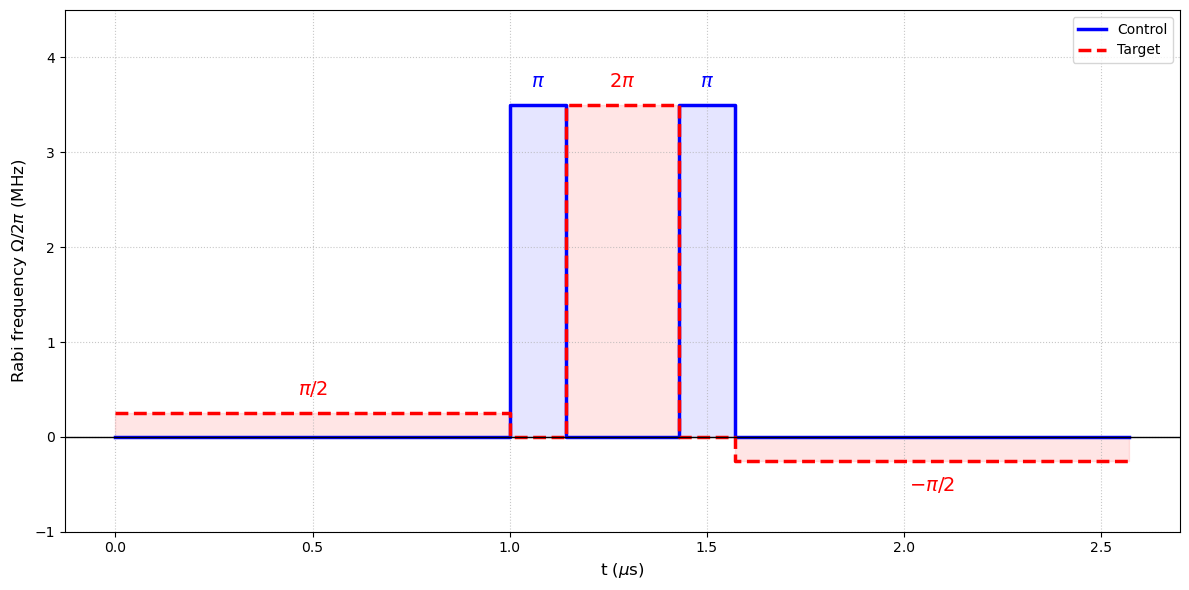

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paràmetres del teu codi
Omega_opt = 2 * np.pi * 3.5      # MHz (òptic)
Omega_mw  = 2 * np.pi * 0.250    # MHz (microones)

# Durades dels polsos
T_pi_2 = np.pi / (2 * Omega_mw)  # Pols pi/2 microones (Target)
T_pi   = np.pi / Omega_opt       # Pols pi òptic (Control)
T_2pi  = 2 * np.pi / Omega_opt   # Pols 2pi òptic (Target)

# temps acumulats per a cada pas del protocol
t0 = 0
t1 = t0 + T_pi_2  
t2 = t1 + T_pi   
t3 = t2 + T_2pi   
t4 = t3 + T_pi    
t5 = t4 + T_pi_2 


temps = [t0, t1, t1, t2, t2, t3, t3, t4, t4, t5]


opt_mhz = Omega_opt / (2 * np.pi)
mw_mhz  = Omega_mw / (2 * np.pi)

# amplituds per a Control i Target
ctrl_rabi = [0, 0, 
             opt_mhz, opt_mhz, 
             0, 0, 
             opt_mhz, opt_mhz, 
             0, 0]

tgt_rabi = [mw_mhz, mw_mhz, 
            0, 0, 
            opt_mhz, opt_mhz, 
            0, 0, 
            -mw_mhz, -mw_mhz]


plt.figure(figsize=(12, 6))

plt.plot(temps, ctrl_rabi, color='blue', linewidth=2.5, label='Control')
plt.plot(temps, tgt_rabi, color='red', linewidth=2.5, linestyle='--', label='Target')

plt.fill_between(temps, ctrl_rabi, color='blue', alpha=0.1)
plt.fill_between(temps, tgt_rabi, color='red', alpha=0.1)




plt.text((t0 + t1)/2, mw_mhz + 0.15, r'$\pi/2$', ha='center', va='bottom', color='red', fontsize=14, fontweight='bold')

plt.text((t1 + t2)/2, opt_mhz + 0.15, r'$\pi$', ha='center', va='bottom', color='blue', fontsize=14, fontweight='bold')

plt.text((t2 + t3)/2, opt_mhz + 0.15, r'$2\pi$', ha='center', va='bottom', color='red', fontsize=14, fontweight='bold')

plt.text((t3 + t4)/2, opt_mhz + 0.15, r'$\pi$', ha='center', va='bottom', color='blue', fontsize=14, fontweight='bold')


plt.text((t4 + t5)/2, -mw_mhz - 0.15, r'$-\pi/2$', ha='center', va='top', color='red', fontsize=14, fontweight='bold')


plt.xlabel('t ($\mu$s)', fontsize=12)
plt.ylabel('Rabi frequency $\Omega/2\pi$ (MHz)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')


plt.ylim(-1.0, 4.5)

plt.tight_layout()
plt.savefig('durada_polsos.png')
plt.show()

### Error sources

When considering realistic physical systems, we must account for the environmental and intrinsic noise sources that can worsen the fidelity of tha gate. These errors manifest mainly as population leakage and phase decoherence.

#### 1. Coherence Times: $T_1$, $T_2$ and $T_2^*$

These times set how long quantum information can be stored and manipulated:

- **$T_1$ (energy relaxation time):**  
  How long an atom stays in an excited state before decaying.  
  Main causes:
  - Spontaneous emission
  - Blackbody radiation: At finite room temperatures, the radiation of the environmnent can act like an additional decay chanel (stimulated emission), shortening the Rydberg lifetime. Instead of decaying to the ground state, BBR drives stimulated transitions to close states. Because these states do not couple to the experimental lasers, the population becomes lost. In some cases, BBR can also provide enough energy to eject the electron entirely (photoionisation) though is not as usual as stimulated emission.


- **$T_2$(coherence time):**  
  How long a superposition keeps a well-defined phase. Usually shorter than T₁.  
  Main causes:
  - Laser phase noise  
  - Doppler effect: atomic thermal motion can induce variations on the frequency that is seen by an atom, introducing dephasing.



- **$T_2^*$ (effective coherence time)**:  
  When the decay is caused by inhomogeneities it is called T₂\*. Is the observed coherence time in a real experiment.



#### 2. Errors in Single-Qubit Gates

- **Pulse errors:** Fluctuations in laser intensity or pulse duration can cause under-rotations or over-rotation on the Bloch sphere causing a uncompleted population transfer to the desired state.
- **Intermediate-state scattering:** When exciting the atoms to the Rydberg state, a two-photon transition can be done by using an intermediate state which atoms breifly occupy. If the laser is not tunned properly, some of the population can go back to the ground state.



#### 3. Errors in Two-Qubit Gates

- **Imperfect blockade:** sometimes both atoms are excited when they shouldn’t be.  
- **Distance fluctuations:** atomic motion changes interaction strength.  
- **Laser-induced forces:** atoms can be displaced or lost from the trap.


In the following code, the CNOT gate following the previous protocol is simulated. The primary error sources contemplated are the spontaneous emission from the Rydberg level and the laser detuning.To rigorously evaluate the performance of the gate, the fidelity is calculated using the quantum state fidelity (Jozsa-Uhlmann fidelity) evaluated exclusively over the computational basis. Unlike a simple population transfer metric, this approach compares the full $9 \times 9$ density matrix of the simulated final state ($\rho_{\text{real}}$) with the ideal target pure state ($|\psi_{\text{ideal}}\rangle$). By doing so, it inherently penalizes any population leakage left in the Rydberg states ($|r\rangle$) at the end of the protocol, as well as any loss of coherence.The average quantum fidelity over the computational basis is defined as:$$F = \frac{1}{4} \sum_{k \in \{00, 01, 10, 11\}} \left[Tr\sqrt{\sqrt{\rho_{ideal}}\rho_{real}\sqrt{\rho_{ideal}}}\right]^2$$where $\rho_{ideal}$ represents the density matrix for each of the states in the ideal case.

We compute a first simulation in which only spontaneuous emission is considered as an error source.


Truth table

In \ Out       00        01        10        11
00          0.9768    0.0155    0.0038    0.0039
01          0.0155    0.9768    0.0039    0.0038
10          0.0000    0.0000    0.0042    0.9958
11          0.0000    0.0000    0.9958    0.0042


 Input |00> -> Fidelity: 97.4751%
 Input |01> -> Fidelity: 97.4751%
 Input |10> -> Fidelity: 99.5551%
 Input |11> -> Fidelity: 99.5551%
 Averaged fidelity: 98.5151%


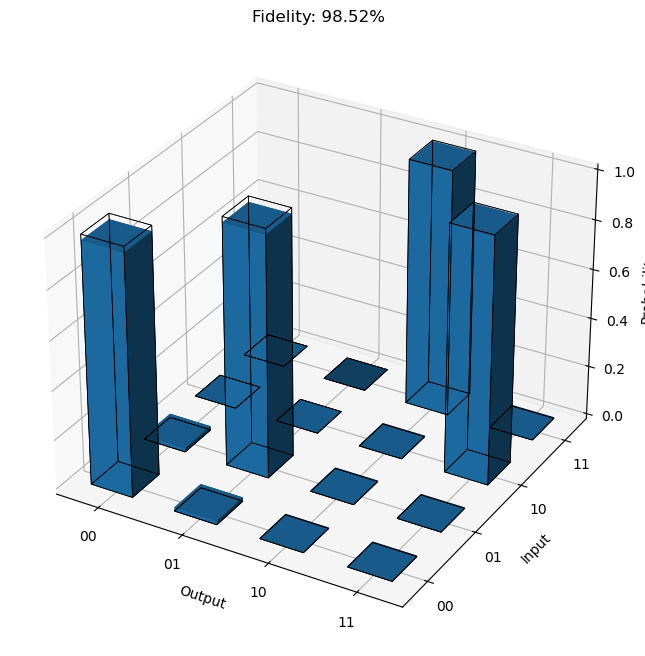

In [20]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


Omega_opt = 2*np.pi*3.5        # MHz transició 0->r o 1->r
Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
Delta = 0.0377*Omega_opt       # detuning 
V_blockade = 2*np.pi*24        # blockade
b = 0.5                        # ratio del decaïment: r -> 0 amb prob. b

# Durades dels polsos
T_pi    = np.pi / Omega_opt        # Pols pi òptic (Control)
T_2pi   = 2 * np.pi / Omega_opt    # Pols 2pi òptic (Target)
T_pi_2  = np.pi / (2 * Omega_mw)   # Pols pi/2 microones (Target)


# Operadors de base i Hamiltonians
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)

def opA(op):
    return qt.tensor(op, I3)

def opB(op):
    return qt.tensor(I3, op)

# Hamiltonians
H_ctrl_drive = (Omega_opt / 2) * (opA(sig_0r) + opA(sig_0r.dag())) \
               - Delta * opA(proj_r)

H_tgt_drive_r = (Omega_opt / 2) * (opB(sig_1r) + opB(sig_1r.dag())) \
                - Delta * opB(proj_r)

H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))

H_blockade = V_blockade * qt.tensor(proj_r, proj_r)

c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]


def evolve(rho, H_drive, T):
    H_total = H_drive + H_blockade
    nsteps = max(50, int(50 * T * max(Omega_opt, Omega_mw)))
    tlist = np.linspace(0, T, nsteps)
    result = qt.mesolve(H_total, rho, tlist, c_ops=c_ops, options={"store_states": True})
    return result.states[-1]

def run_protocol(rho0):
    rho = rho0
    rho = evolve(rho, H_tgt_drive_01_pos, T_pi_2)
    rho = evolve(rho, H_ctrl_drive,        T_pi)
    rho = evolve(rho, H_tgt_drive_r,       T_2pi)
    rho = evolve(rho, H_ctrl_drive,        T_pi)
    rho = evolve(rho, H_tgt_drive_01_neg, T_pi_2)
    return rho


# Truth table
basis_labels = ['00', '01', '0r', '10', '11', '1r', 'r0', 'r1', 'rr']
basis_states = []
for ia in [ket0, ket1, ketr]:
    for ib in [ket0, ket1, ketr]:
        basis_states.append(qt.tensor(ia, ib))

def compute_final_probs(rho):
    pops = np.array([qt.expect(s * s.dag(), rho).real for s in basis_states])
    p = dict(zip(basis_labels, pops))

    P00 = (p['00'] + b * p['0r'] + b * p['r0'] + b * b * p['rr'])
    P01 = (p['01'] + (1 - b) * p['0r'] + b * p['r1'] + b * (1 - b) * p['rr'])
    P10 = (p['10'] + b * p['1r'] + (1 - b) * p['r0'] + (1 - b) * b * p['rr'])
    P11 = (p['11'] + (1 - b) * p['1r'] + (1 - b) * p['r1'] + (1 - b)**2 * p['rr'])
    return np.array([P00, P01, P10, P11])

init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0),
    '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0),
    '11': qt.tensor(ket1, ket1),
}

truth_table = np.zeros((4, 4))
for i, lbl in enumerate(init_labels):
    psi0 = init_states[lbl]
    rho0 = psi0 * psi0.dag()
    rho_final = run_protocol(rho0)
    truth_table[i, :] = compute_final_probs(rho_final)

print("\nTruth table\n")
print("In \\ Out       00        01        10        11")
for i, inp in enumerate(init_labels):
    probs_str = "    ".join([f"{p:6.4f}" for p in truth_table[i]])
    print(f"{inp}          {probs_str}")
print("\n")

ideal = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
])

#Calcul fidelitat

ideal_outcomes = {
    '00': qt.tensor(ket0, ket0), 
    '01': qt.tensor(ket0, ket1), 
    '10': qt.tensor(ket1, ket1), 
    '11': qt.tensor(ket1, ket0), 
}

fidelitats_q = []



for lbl in init_labels:
    rho0 = init_states[lbl] * init_states[lbl].dag()
    
    
    rho_final = run_protocol(rho0) 
    
    # Matriu ideal
    rho_ideal = ideal_outcomes[lbl] * ideal_outcomes[lbl].dag()
    
    #fidelitat
    f = qt.metrics.fidelity(rho_final, rho_ideal)**2
    fidelitats_q.append(f)
    
    print(f" Input |{lbl}> -> Fidelity: {f * 100:.4f}%")

fidelitat_final_q = np.mean(fidelitats_q)

print(f" Averaged fidelity: {fidelitat_final_q * 100:.4f}%")



fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
_x = np.arange(4)
_y = np.arange(4)
_xx, _yy = np.meshgrid(_x, _y)
x, y = _xx.ravel(), _yy.ravel()

top_sim = truth_table.ravel()
top_ideal = ideal.ravel()
bottom = np.zeros_like(top_sim)
width = depth = 0.5

empty_colors = [(0, 0, 0, 0)] * 16 
ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_ideal, 
         shade=False, color=empty_colors, edgecolor='black', linewidth=0.5, zsort='max')

ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_sim, shade=True, alpha=1)

ax.set_xticks(_x)
ax.set_xticklabels(init_labels)
ax.set_yticks(_y)
ax.set_yticklabels(init_labels)
ax.set_xlabel('Output')
ax.set_ylabel('Input')
ax.set_zlabel('Probability')


ax.set_title(f'Fidelity: {fidelitat_final_q*100:.2f}%')

plt.savefig('cnot_implementation.png')
plt.show()

We can study de dependence of the fidelity on the Rabi frequency that couples the $|0\rangle$ state to the rydberg state and the detuning.

In [ ]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt



Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
V_blockade = 2*np.pi*24        # blockade en MHz
b = 0.5                        # ratio del decaïment

#operadors base i hamiltonians
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)
def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos de microones i interacció
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)

# Operadors de decaïment 
c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

# Estats inicials i ideals 
init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0), '11': qt.tensor(ket1, ket1),
}
ideal_outcomes = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket1), '11': qt.tensor(ket1, ket0),
}

def avalua_fidelitat_cnot(Omega_opt_val, Delta_val):
    """Calcula la fidelitat de la porta per a uns valors concrets d'Omega i Delta."""
    
    # Temps dels polsos
    T_pi    = np.pi / Omega_opt_val
    T_2pi   = 2 * np.pi / Omega_opt_val
    T_pi_2  = np.pi / (2 * Omega_mw) 

    # Hamiltonians òptics dependents de la iteració
    H_ctrl_drive = (Omega_opt_val / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta_val * opA(proj_r)
    H_tgt_drive_r = (Omega_opt_val / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta_val * opB(proj_r)

    
    def evolve_fast(rho, H_drive, T):
        H_total = H_drive + H_blockade
        result = qt.mesolve(H_total, rho, [0.0, T], c_ops=c_ops, options={"nsteps": 100000000})
        return result.states[-1]

    # Protocol de 5 polsos
    def run_protocol_fast(rho0):
        rho = evolve_fast(rho0, H_tgt_drive_01_pos, T_pi_2)
        rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
        rho = evolve_fast(rho, H_tgt_drive_r,       T_2pi)
        rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
        rho = evolve_fast(rho, H_tgt_drive_01_neg, T_pi_2)
        return rho

    # Càlcul de la Fidelitat 
    fidelitats = []
    for lbl in init_labels:
        rho0 = init_states[lbl] * init_states[lbl].dag()
        rho_final = run_protocol_fast(rho0)
        rho_ideal = ideal_outcomes[lbl] * ideal_outcomes[lbl].dag()
        
        f = qt.metrics.fidelity(rho_final, rho_ideal)**2
        fidelitats.append(f)
        
    return np.mean(fidelitats)

#punts a avaluar (amb 500 m'ha tardat 6h)
punts_omega = 20  
punts_delta = 20

# Creem els arrays de valors 
omega_array_MHz = np.linspace(0.1, 30.0, punts_omega) 
delta_array_MHz = np.linspace(-5, 5, punts_delta) 

Fidelity_matrix = np.zeros((punts_delta, punts_omega))

# execució del bucle

for i, o_val_MHz in enumerate(omega_array_MHz):
    for j, d_val_MHz in enumerate(delta_array_MHz):
        
        Omega_rad = 2 * np.pi * o_val_MHz
        Delta_rad = 2 * np.pi * d_val_MHz
        
        # Avaluem i guardem a la matriu
        F_val = avalua_fidelitat_cnot(Omega_rad, Delta_rad)
        Fidelity_matrix[j, i] = F_val
        
    
    print(f" > Columna {i+1}/{punts_omega} completada (Omega = {o_val_MHz:.2f} MHz).")



# punt de màxima fielitat
idx_max = np.unravel_index(np.argmax(Fidelity_matrix, axis=None), Fidelity_matrix.shape)

best_delta_MHz = delta_array_MHz[idx_max[0]]
best_omega_MHz = omega_array_MHz[idx_max[1]]
max_f = Fidelity_matrix[idx_max]

print("-" * 54)
print(f"MAXIMUM FIDELITY: {max_f*100:.2f}%")
print(f"Optimal point: Omega_opt = $2\pi$ {best_omega_MHz:.3f} MHz, Delta = $2\pi$ {best_delta_MHz:.3f} MHz")
print("-" * 54)

# heatmap
fig, ax = plt.subplots(figsize=(9, 7))

X, Y = np.meshgrid(omega_array_MHz, delta_array_MHz)
heatmap = ax.pcolormesh(X, Y, Fidelity_matrix * 100, shading='auto', cmap='viridis', vmin=0, vmax=100)


cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Fidelity (%)', rotation=270, labelpad=15, fontsize=12)


ax.plot(best_omega_MHz, best_delta_MHz, 'r*', markersize=15, 
        label=f'Optimal point ({max_f*100:.1f}%)', markeredgecolor='black', markeredgewidth=0.5)

ax.axvline(best_omega_MHz, color='white', linestyle='--', alpha=0.4)
ax.axhline(best_delta_MHz, color='white', linestyle='--', alpha=0.4)


ax.set_xlabel('Optical Rabi Frequency $\Omega_{opt} / 2\pi$ (MHz)', fontsize=12)
ax.set_ylabel('Laser Detuning $\Delta / 2\pi$ (MHz)', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
# plt.savefig('cnot_fidelity_heatmap.pdf') 
plt.show()

If we take a closer look at how the fidelity behaves for a the maximum detuning obtanined $\Delta=-2\pi\times 0.010\,\mathrm{MHz}$:

Iniciant escombrat de paràmetres: 500 iteracions pendents...
 > Iteració 1/500 completada (Omega = 0.10 MHz).
 > Iteració 50/500 completada (Omega = 3.04 MHz).
 > Iteració 100/500 completada (Omega = 6.03 MHz).
 > Iteració 150/500 completada (Omega = 9.03 MHz).
 > Iteració 200/500 completada (Omega = 12.02 MHz).
 > Iteració 250/500 completada (Omega = 15.02 MHz).
 > Iteració 300/500 completada (Omega = 18.02 MHz).
 > Iteració 350/500 completada (Omega = 21.01 MHz).
 > Iteració 400/500 completada (Omega = 24.01 MHz).
 > Iteració 450/500 completada (Omega = 27.00 MHz).
 > Iteració 500/500 completada (Omega = 30.00 MHz).
------------------------------------------------------
MAXIMUM FIDELITY: 99.04%
Optimal point: Omega_opt = 2π * 2.677 MHz, Delta = 2π * -0.010 MHz
------------------------------------------------------


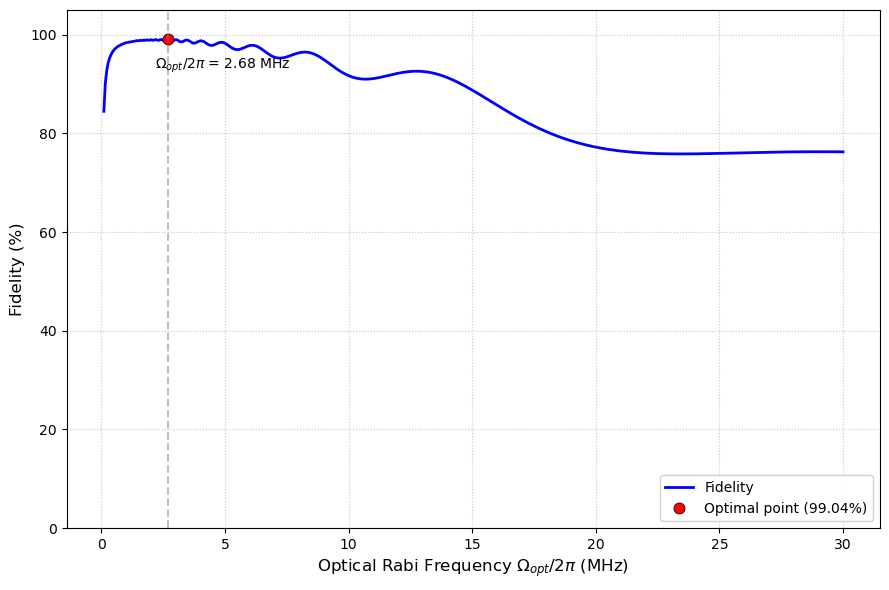

In [1]:
#slice de la fidelity (fidelity per un detuning determinat)

# ERROR SOURCES CONSIDERED:
# - Spontaneous emission

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
V_blockade = 2*np.pi*24        # blockade en MHz
b = 0.5                        # ratio del decaïment

# operadors base i hamiltonians
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)
def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos de microones i interacció
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)

# Operadors de decaïment 
c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

# Estats inicials i ideals 
init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0), '11': qt.tensor(ket1, ket1),
}
ideal_outcomes = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket1), '11': qt.tensor(ket1, ket0),
}

def avalua_fidelitat_cnot(Omega_opt_val, Delta_val):
    """Calcula la fidelitat de la porta per a uns valors concrets d'Omega i Delta."""
    
    # Temps dels polsos
    T_pi    = np.pi / Omega_opt_val
    T_2pi   = 2 * np.pi / Omega_opt_val
    T_pi_2  = np.pi / (2 * Omega_mw) 

    # Hamiltonians òptics dependents de la iteració
    H_ctrl_drive = (Omega_opt_val / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta_val * opA(proj_r)
    H_tgt_drive_r = (Omega_opt_val / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta_val * opB(proj_r)

    
    def evolve_fast(rho, H_drive, T):
        H_total = H_drive + H_blockade
        result = qt.mesolve(H_total, rho, [0.0, T], c_ops=c_ops, options={"nsteps": 100000000})
        return result.states[-1]

    # Protocol de 5 polsos
    def run_protocol_fast(rho0):
        rho = evolve_fast(rho0, H_tgt_drive_01_pos, T_pi_2)
        rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
        rho = evolve_fast(rho, H_tgt_drive_r,       T_2pi)
        rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
        rho = evolve_fast(rho, H_tgt_drive_01_neg, T_pi_2)
        return rho

    # Càlcul de la Fidelitat 
    fidelitats = []
    for lbl in init_labels:
        rho0 = init_states[lbl] * init_states[lbl].dag()
        rho_final = run_protocol_fast(rho0)
        rho_ideal = ideal_outcomes[lbl] * ideal_outcomes[lbl].dag()
        
        f = qt.metrics.fidelity(rho_final, rho_ideal)**2
        fidelitats.append(f)
        
    return np.mean(fidelitats)

# punts a avaluar
punts_omega = 500


Delta_fixa_MHz = -0.01  


# Creem els arrays de valors 
omega_array_MHz = np.linspace(0.1, 30.0, punts_omega) 

Fidelity_array = np.zeros(punts_omega)

# execució del bucle
print(f"Iniciant escombrat de paràmetres: {punts_omega} iteracions pendents...")

Delta_rad = 2 * np.pi * Delta_fixa_MHz

for i, o_val_MHz in enumerate(omega_array_MHz):
    
    Omega_rad = 2 * np.pi * o_val_MHz
    
    # Avaluem i guardem a l'array
    F_val = avalua_fidelitat_cnot(Omega_rad, Delta_rad)
    Fidelity_array[i] = F_val
    
    # Només imprimim cada 50 iteracions per no saturar la consola
    if (i + 1) % 50 == 0 or i == 0:
        print(f" > Iteració {i+1}/{punts_omega} completada (Omega = {o_val_MHz:.2f} MHz).")

# punt de màxima fidelitat
idx_max = np.argmax(Fidelity_array)
best_omega_MHz = omega_array_MHz[idx_max]
max_f = Fidelity_array[idx_max]

print("-" * 54)
print(f"MAXIMUM FIDELITY: {max_f*100:.2f}%")
print(f"Optimal point: Omega_opt = 2π * {best_omega_MHz:.3f} MHz, Delta = 2π * {Delta_fixa_MHz:.3f} MHz")
print("-" * 54)

fig, ax = plt.subplots(figsize=(9, 6))


ax.plot(omega_array_MHz, Fidelity_array * 100, color='blue', linewidth=2, label=f'Fidelity')

ax.plot(best_omega_MHz, max_f * 100, 'ro', markersize=8, 
        label=f'Optimal point ({max_f*100:.2f}%)', markeredgecolor='black', markeredgewidth=0.5)


ax.text(best_omega_MHz-0.5, (max_f * 100) - 6, 
        f'$\Omega_{{opt}}/2\pi$ = {best_omega_MHz:.2f} MHz',
        fontsize=10 )

ax.axvline(best_omega_MHz, color='gray', linestyle='--', alpha=0.5)



ax.set_xlabel(r'Optical Rabi Frequency $\Omega_{opt} / 2\pi$ (MHz)', fontsize=12)
ax.set_ylabel('Fidelity (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('slice_fidelity_0.01_det.pdf')
plt.show()

Now we can add another error source, in this case, the fact that different atoms can "see" different optical Rabi frequencies. To simulate that, we consider a Gaussian distribution centered to a given Rabi frequency and we simulate the protocol for 10 random values that follow the distribution. After that we average the density matrix and with the one obtained, we calculate the fidelity of the process.

Calculant taula de veritat (10 shots per estat)...

Truth table

In \ Out       00        01        10        11
00          0.9635    0.0202    0.0082    0.0081
01          0.0184    0.9682    0.0068    0.0067
10          0.0000    0.0000    0.0173    0.9827
11          0.0000    0.0000    0.9847    0.0153




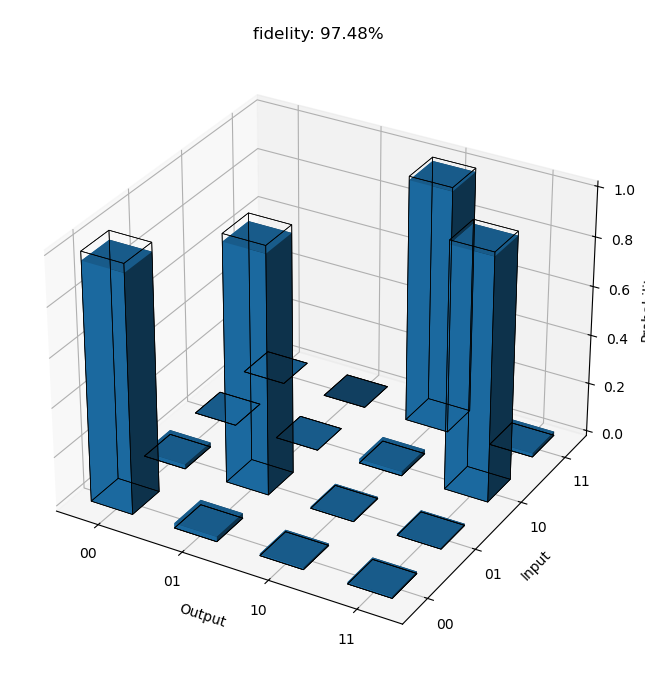

In [2]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
# - Laser inhomogeneties (different atoms see different optical rabi frequencies) 


import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


Omega_opt_nom = 2*np.pi*3.5    # MHz transició 0->r o 1->r (Valor Nominal)
Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
Delta = 0.0377*Omega_opt_nom   # detuning 
V_blockade = 2*np.pi*24        # blockade
b = 0.5                        # ratio del decaïment: r -> 0 amb prob. b

#soroll
num_shots = 10                 
desv_est_relativa = 0.05       
sigma_omega = desv_est_relativa * Omega_opt_nom

# Durades dels polsos (fixades pel valor central)
T_pi    = np.pi / Omega_opt_nom        
T_2pi   = 2 * np.pi / Omega_opt_nom    
T_pi_2  = np.pi / (2 * Omega_mw)   


ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)

def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos 
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)


c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

def evolve(rho, H_drive, T):
    H_total = H_drive + H_blockade
    nsteps = max(50, int(50 * T * max(Omega_opt_nom, Omega_mw)))
    tlist = np.linspace(0, T, nsteps)
    result = qt.mesolve(H_total, rho, tlist, c_ops=c_ops, options={"store_states": True})
    return result.states[-1]


basis_labels = ['00', '01', '0r', '10', '11', '1r', 'r0', 'r1', 'rr']
basis_states = []
for ia in [ket0, ket1, ketr]:
    for ib in [ket0, ket1, ketr]:
        basis_states.append(qt.tensor(ia, ib))

def compute_final_probs(rho):
    pops = np.array([qt.expect(s * s.dag(), rho).real for s in basis_states])
    p = dict(zip(basis_labels, pops))

    P00 = (p['00'] + b * p['0r'] + b * p['r0'] + b * b * p['rr'])
    P01 = (p['01'] + (1 - b) * p['0r'] + b * p['r1'] + b * (1 - b) * p['rr'])
    P10 = (p['10'] + b * p['1r'] + (1 - b) * p['r0'] + (1 - b) * b * p['rr'])
    P11 = (p['11'] + (1 - b) * p['1r'] + (1 - b) * p['r1'] + (1 - b)**2 * p['rr'])
    return np.array([P00, P01, P10, P11])

init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0),
    '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0),
    '11': qt.tensor(ket1, ket1),
}

truth_table = np.zeros((4, 4))

print(f"Calculant taula de veritat ({num_shots} shots per estat)...")

for i, lbl in enumerate(init_labels):
    psi0 = init_states[lbl]
    rho0 = psi0 * psi0.dag()
    
    rho_final_avg = 0
    
    for _ in range(num_shots):
        
        Omega_shot = np.random.normal(Omega_opt_nom, sigma_omega)
        
        # Definim els Hamiltonians òptics amb l'Omega aleatoria
        H_ctrl_shot = (Omega_shot / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta * opA(proj_r)
        H_tgt_shot  = (Omega_shot / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta * opB(proj_r)
        
        # protocol per aquesta OMEga
        rho_shot = rho0
        rho_shot = evolve(rho_shot, H_tgt_drive_01_pos, T_pi_2)
        rho_shot = evolve(rho_shot, H_ctrl_shot,        T_pi)
        rho_shot = evolve(rho_shot, H_tgt_shot,         T_2pi)
        rho_shot = evolve(rho_shot, H_ctrl_shot,        T_pi)
        rho_shot = evolve(rho_shot, H_tgt_drive_01_neg, T_pi_2)
        
        rho_final_avg += rho_shot
        
    # Fem la mitjana de l'estat mixt final
    rho_final_avg /= num_shots
    
    # Calculem la probabilitat final sobre l'estat mitjà
    truth_table[i, :] = compute_final_probs(rho_final_avg)

print("\nTruth table\n")
print("In \ Out       00        01        10        11")
for i, inp in enumerate(init_labels):
    probs_str = "    ".join([f"{p:6.4f}" for p in truth_table[i]])
    print(f"{inp}          {probs_str}")
print("\n")

ideal = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
])


fidelity = np.mean([truth_table[0,0], truth_table[1,1], truth_table[2,3], truth_table[3,2]])

# --- Creació del Gràfic 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
_x = np.arange(4)
_y = np.arange(4)
_xx, _yy = np.meshgrid(_x, _y)
x, y = _xx.ravel(), _yy.ravel()

top_sim = truth_table.ravel()
top_ideal = ideal.ravel()
bottom = np.zeros_like(top_sim)
width = depth = 0.5

empty_colors = [(0, 0, 0, 0)] * 16 
ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_ideal, 
         shade=False, color=empty_colors, edgecolor='black', linewidth=0.5, zsort='max')

ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_sim, shade=True, alpha=1)

ax.set_xticks(_x)
ax.set_xticklabels(init_labels)
ax.set_yticks(_y)
ax.set_yticklabels(init_labels)
ax.set_xlabel('Output')
ax.set_ylabel('Input')
ax.set_zlabel('Probability')

ax.set_title(f'\nfidelity: {fidelity*100:.2f}%')

# plt.savefig('cnot_bona_soroll.pdf')
plt.show()

In [ ]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
# - Laser inhomogeneties (different atoms see different optical rabi frequencies) 

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
V_blockade = 2*np.pi*24        # blockade en MHz
b = 0.5                        # ratio del decaïment

# Operadors base i hamiltonians
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)
def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos de microones i interacció
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)

# Operadors de decaïment 
c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

# Estats inicials i ideals 
init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0), '11': qt.tensor(ket1, ket1),
}
ideal_outcomes = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket1), '11': qt.tensor(ket1, ket0),
}

def avalua_fidelitat_cnot(Omega_opt_val_ideal, Delta_val, num_shots=10, desv_est_relativa=0.05):
    
    # Els temps dels polsos es calibren en funció del valor IDEAL 
    T_pi    = np.pi / Omega_opt_val_ideal
    T_2pi   = 2 * np.pi / Omega_opt_val_ideal
    T_pi_2  = np.pi / (2 * Omega_mw) 
    
    # Desviació estàndard del soroll làser 
    sigma_omega = desv_est_relativa * Omega_opt_val_ideal
    
    def evolve_fast(rho, H_drive, T):
        H_total = H_drive + H_blockade
        result = qt.mesolve(H_total, rho, [0.0, T], c_ops=c_ops, options={"nsteps": 100000})
        return result.states[-1]

    fidelitats = []
    
    for lbl in init_labels:
        rho0 = init_states[lbl] * init_states[lbl].dag()
        rho_ideal = ideal_outcomes[lbl] * ideal_outcomes[lbl].dag()
        
        # Matriu densitat acumuladora per a aquest estat inicial
        rho_final_avg = 0 
        
        for _ in range(num_shots):
            # Inhomogeneïtat làser: mostregem una nova Omega d'una Gaussiana
            Omega_shot = np.random.normal(Omega_opt_val_ideal, sigma_omega)
            
            # Els Hamiltonians per aquest "shot" concret
            H_ctrl_drive = (Omega_shot / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta_val * opA(proj_r)
            H_tgt_drive_r = (Omega_shot / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta_val * opB(proj_r)
            
            # Protocol de 5 polsos (notar que utilitzem els temps fixos T_pi i T_2pi, però els H fluctuants)
            rho = evolve_fast(rho0, H_tgt_drive_01_pos, T_pi_2)
            rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
            rho = evolve_fast(rho, H_tgt_drive_r,       T_2pi)
            rho = evolve_fast(rho, H_ctrl_drive,        T_pi)
            rho = evolve_fast(rho, H_tgt_drive_01_neg,  T_pi_2)
            
            rho_final_avg += rho
            
        # Fem la mitjana de la matriu densitat d'acord amb els shots realitzats
        rho_final_avg = rho_final_avg / num_shots
        
        # Un cop tenim l'estat mixt final mitjà, calculem la fidelitat amb el cas ideal
        f = qt.metrics.fidelity(rho_final_avg, rho_ideal)**2
        fidelitats.append(f)
        
    return np.mean(fidelitats)


punts_omega = 300
punts_delta = 300

# Creem els arrays de valors 
omega_array_MHz = np.linspace(0.1, 25.0, punts_omega) 
delta_array_MHz = np.linspace(-5, 5, punts_delta) 

Fidelity_matrix = np.zeros((punts_delta, punts_omega))

# Execució del bucle
print(f"Iniciant escombrat de paràmetres: {punts_omega * punts_delta} iteracions pendents...")
print(f"Cada iteració inclou 10 simulacions per cada un dels 4 estats de la base.")

for i, o_val_MHz in enumerate(omega_array_MHz):
    for j, d_val_MHz in enumerate(delta_array_MHz):
        
        Omega_rad = 2 * np.pi * o_val_MHz
        Delta_rad = 2 * np.pi * d_val_MHz
        
        
        F_val = avalua_fidelitat_cnot(Omega_rad, Delta_rad, num_shots=10, desv_est_relativa=0.05)
        Fidelity_matrix[j, i] = F_val
        
    print(f" > Columna {i+1}/{punts_omega} completada (Omega nominal = {o_val_MHz:.2f} MHz).")

# Punt de màxima fidelitat
idx_max = np.unravel_index(np.argmax(Fidelity_matrix, axis=None), Fidelity_matrix.shape)

best_delta_MHz = delta_array_MHz[idx_max[0]]
best_omega_MHz = omega_array_MHz[idx_max[1]]
max_f = Fidelity_matrix[idx_max]

print("-" * 54)
print(f"MAXIMUM FIDELITY (Amb 5% de soroll Làser): {max_f*100:.2f}%")
print(f"Optimal point: Omega_opt = $2\pi$ {best_omega_MHz:.3f} MHz, Delta = $2\pi$ {best_delta_MHz:.3f} MHz")
print("-" * 54)



fig, ax = plt.subplots(figsize=(9, 7))

X, Y = np.meshgrid(omega_array_MHz, delta_array_MHz)
heatmap = ax.pcolormesh(X, Y, Fidelity_matrix * 100, shading='auto', cmap='viridis', vmin=0, vmax=100)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Fidelity (%)', rotation=270, labelpad=15, fontsize=12)

ax.plot(best_omega_MHz, best_delta_MHz, 'r*', markersize=15, 
        label=f'Optimal point ({max_f*100:.1f}%)', markeredgecolor='black', markeredgewidth=0.5)

ax.axvline(best_omega_MHz, color='white', linestyle='--', alpha=0.4)
ax.axhline(best_delta_MHz, color='white', linestyle='--', alpha=0.4)

# Estil del gràfic
ax.set_xlabel(r'Optical Rabi Frequency $\Omega_{opt} / 2\pi$ (MHz)', fontsize=12)
ax.set_ylabel(r'Laser Detuning $\Delta / 2\pi$ (MHz)', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('fidelity_heatmap_inhomogeneitats_laser.pdf')
plt.show()

Finally we can add another error source such as that the laser pulses have some inhomogeneities in time, meaning that the pulses may not have the exact time needed to drive the transition given by the protocol.

Calculant taula de veritat (100 shots per estat)...

Truth table

In \ Out       00        01        10        11
00          0.9659    0.0189    0.0075    0.0077
01          0.0191    0.9660    0.0074    0.0076
10          0.0000    0.0000    0.0121    0.9879
11          0.0000    0.0000    0.9875    0.0125




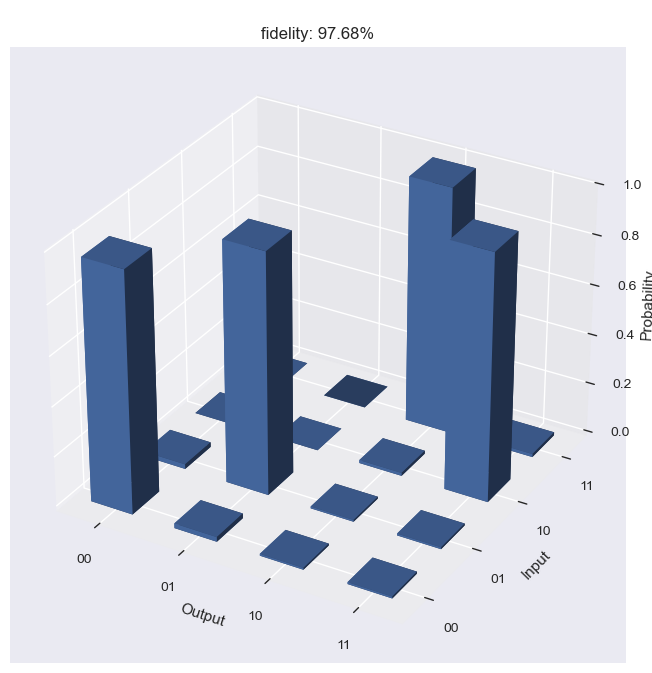

In [14]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
# - Laser inhomogeneties (different atoms see different optical rabi frequencies) 
# - Time inhomogeneties (fluctuations in laser pulses time)

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


Omega_opt_nom = 2*np.pi*3.5    # MHz optic (valor central)
Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
Delta = 0.0377*Omega_opt_nom   # detuning 
V_blockade = 2*np.pi*24        # blockade
b = 0.5                        # ratio del decaïment: r -> 0 amb prob. b

#soroll
num_shots = 100                
desv_est_omega = 0.05          
desv_est_temps = 0.02          

sigma_omega = desv_est_omega * Omega_opt_nom

# Durades dels polsos (Valors ideals)
T_pi_nom    = np.pi / Omega_opt_nom        
T_2pi_nom   = 2 * np.pi / Omega_opt_nom    
T_pi_2_nom  = np.pi / (2 * Omega_mw)   

# --- Base i Operadors ---
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)

def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos 
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)


c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

def evolve(rho, H_drive, T):
    # si el soroll fa que el temps sigui molt petit, no evoluciona
    if T <= 1e-12:
        return rho
    H_total = H_drive + H_blockade
    nsteps = max(50, int(50 * T * max(Omega_opt_nom, Omega_mw)))
    tlist = np.linspace(0, T, nsteps)
    result = qt.mesolve(H_total, rho, tlist, c_ops=c_ops, options={"store_states": True})
    return result.states[-1]


basis_labels = ['00', '01', '0r', '10', '11', '1r', 'r0', 'r1', 'rr']
basis_states = []
for ia in [ket0, ket1, ketr]:
    for ib in [ket0, ket1, ketr]:
        basis_states.append(qt.tensor(ia, ib))

def compute_final_probs(rho):
    pops = np.array([qt.expect(s * s.dag(), rho).real for s in basis_states])
    p = dict(zip(basis_labels, pops))

    P00 = (p['00'] + b * p['0r'] + b * p['r0'] + b * b * p['rr'])
    P01 = (p['01'] + (1 - b) * p['0r'] + b * p['r1'] + b * (1 - b) * p['rr'])
    P10 = (p['10'] + b * p['1r'] + (1 - b) * p['r0'] + (1 - b) * b * p['rr'])
    P11 = (p['11'] + (1 - b) * p['1r'] + (1 - b) * p['r1'] + (1 - b)**2 * p['rr'])
    return np.array([P00, P01, P10, P11])

init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0),
    '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0),
    '11': qt.tensor(ket1, ket1),
}

truth_table = np.zeros((4, 4))

print(f"Calculant taula de veritat ({num_shots} shots per estat)...")

for i, lbl in enumerate(init_labels):
    psi0 = init_states[lbl]
    rho0 = psi0 * psi0.dag()
    
    rho_final_avg = 0
    
    for _ in range(num_shots):
        # Fluctuació a la freqüència de Rabi
        Omega_shot = np.random.normal(Omega_opt_nom, sigma_omega)
        
        # Fluctuacions als temps dels polsos 
        T_pi_shot   = max(0.0, np.random.normal(T_pi_nom,   desv_est_temps * T_pi_nom))
        T_2pi_shot  = max(0.0, np.random.normal(T_2pi_nom,  desv_est_temps * T_2pi_nom))
        T_pi_2_shot = max(0.0, np.random.normal(T_pi_2_nom, desv_est_temps * T_pi_2_nom))
        
        # Definim els Hamiltonians òptics per aquesta freqûència
        H_ctrl_shot = (Omega_shot / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta * opA(proj_r)
        H_tgt_shot  = (Omega_shot / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta * opB(proj_r)
        
        # Executem el protocol amb els Hamiltonians I els temps propis d'aquest shot
        rho_shot = rho0
        rho_shot = evolve(rho_shot, H_tgt_drive_01_pos, T_pi_2_shot)
        rho_shot = evolve(rho_shot, H_ctrl_shot,        T_pi_shot)
        rho_shot = evolve(rho_shot, H_tgt_shot,         T_2pi_shot)
        rho_shot = evolve(rho_shot, H_ctrl_shot,        T_pi_shot)
        rho_shot = evolve(rho_shot, H_tgt_drive_01_neg, T_pi_2_shot)
        
        rho_final_avg += rho_shot
        
    # Fem la mitjana de l'estat mixt final
    rho_final_avg /= num_shots
    
    # Calculem la probabilitat final sobre l'estat mitjà
    truth_table[i, :] = compute_final_probs(rho_final_avg)

print("\nTruth table\n")
print("In \ Out       00        01        10        11")
for i, inp in enumerate(init_labels):
    probs_str = "    ".join([f"{p:6.4f}" for p in truth_table[i]])
    print(f"{inp}          {probs_str}")
print("\n")

ideal = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
])

fidelity = np.mean([truth_table[0,0], truth_table[1,1], truth_table[2,3], truth_table[3,2]])


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
_x = np.arange(4)
_y = np.arange(4)
_xx, _yy = np.meshgrid(_x, _y)
x, y = _xx.ravel(), _yy.ravel()

top_sim = truth_table.ravel()
top_ideal = ideal.ravel()
bottom = np.zeros_like(top_sim)
width = depth = 0.5

#empty_colors = [(0, 0, 0, 0)] * 16 
#ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_ideal, 
         #shade=False, color=empty_colors, edgecolor='black', linewidth=0.5, zsort='max')

ax.bar3d(x - width/2, y - depth/2, bottom, width, depth, top_sim, shade=True, alpha=1)

ax.set_xticks(_x)
ax.set_xticklabels(init_labels)
ax.set_yticks(_y)
ax.set_yticklabels(init_labels)
ax.set_xlabel('Output')
ax.set_ylabel('Input')
ax.set_zlabel('Probability')

ax.set_title(f'\nfidelity: {fidelity*100:.2f}%')

plt.show()

In [3]:
# ERROR SOURCES CONSIDERED:
# - Spontaneous emission
# - Laser inhomogeneties (different atoms see different optical rabi frequencies) 
# - Time inhomogeneties (fluctuations in laser pulses time)

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


Omega_mw  = 2*np.pi*0.250      # MHz 0->1
Gamma = 1.0/51.0       
V_blockade = 2*np.pi*24        # blockade en MHz
b = 0.5                        # ratio del decaïment

# Operadors base i hamiltonians
ket0 = qt.basis(3, 0)
ket1 = qt.basis(3, 1)
ketr = qt.basis(3, 2)

sig_0r = ket0 * ketr.dag()
sig_1r = ket1 * ketr.dag()
sig_01 = ket0 * ket1.dag()
proj_r = ketr * ketr.dag()

I3 = qt.qeye(3)
def opA(op): return qt.tensor(op, I3)
def opB(op): return qt.tensor(I3, op)

# Hamiltonians fixos de microones i interacció
H_tgt_drive_01_pos = (Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_tgt_drive_01_neg = -(Omega_mw / 2) * (opB(sig_01) + opB(sig_01.dag()))
H_blockade = V_blockade * qt.tensor(proj_r, proj_r)


c_ops = [
    np.sqrt(b * Gamma)       * opA(sig_0r),
    np.sqrt((1 - b) * Gamma) * opA(sig_1r),
    np.sqrt(b * Gamma)       * opB(sig_0r),
    np.sqrt((1 - b) * Gamma) * opB(sig_1r),
]

 
init_labels = ['00', '01', '10', '11']
init_states = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket0), '11': qt.tensor(ket1, ket1),
}
ideal_outcomes = {
    '00': qt.tensor(ket0, ket0), '01': qt.tensor(ket0, ket1),
    '10': qt.tensor(ket1, ket1), '11': qt.tensor(ket1, ket0),
}

def avalua_fidelitat_cnot(Omega_opt_val_ideal, Delta_val, num_shots=10, desv_est_omega=0.05, desv_est_temps=0.02):

    
    # Temps dels polsos basats en els valors ideals
    T_pi_nom    = np.pi / Omega_opt_val_ideal
    T_2pi_nom   = 2 * np.pi / Omega_opt_val_ideal
    T_pi_2_nom  = np.pi / (2 * Omega_mw) 
    
    # Desviació estàndard del soroll de Rabi
    sigma_omega = desv_est_omega * Omega_opt_val_ideal
    
    def evolve_fast(rho, H_drive, T):
        if T <= 1e-12:
            return rho
        H_total = H_drive + H_blockade
        
        nsteps = 100000000
        result = qt.mesolve(H_total, rho, [0.0, T], c_ops=c_ops, options={"nsteps": nsteps})
        return result.states[-1]

    fidelitats = []
    
    for lbl in init_labels:
        rho0 = init_states[lbl] * init_states[lbl].dag()
        rho_ideal = ideal_outcomes[lbl] * ideal_outcomes[lbl].dag()
        
        rho_final_avg = 0 
        
        for _ in range(num_shots):
            # 1. Inhomogeneïtat làser (omega)
            Omega_shot = np.random.normal(Omega_opt_val_ideal, sigma_omega)
            
            # 2. Inhomogeneïtat del temps
            T_pi_shot   = max(0.0, np.random.normal(T_pi_nom,   desv_est_temps * T_pi_nom))
            T_2pi_shot  = max(0.0, np.random.normal(T_2pi_nom,  desv_est_temps * T_2pi_nom))
            T_pi_2_shot = max(0.0, np.random.normal(T_pi_2_nom, desv_est_temps * T_pi_2_nom))
            
            # Hamiltonians del shot
            H_ctrl_shot = (Omega_shot / 2) * (opA(sig_0r) + opA(sig_0r.dag())) - Delta_val * opA(proj_r)
            H_tgt_shot = (Omega_shot / 2) * (opB(sig_1r) + opB(sig_1r.dag())) - Delta_val * opB(proj_r)
            
            # Execució del protocol per a aquest shot específic
            rho = evolve_fast(rho0, H_tgt_drive_01_pos, T_pi_2_shot)
            rho = evolve_fast(rho, H_ctrl_shot,        T_pi_shot)
            rho = evolve_fast(rho, H_tgt_shot,         T_2pi_shot)
            rho = evolve_fast(rho, H_ctrl_shot,        T_pi_shot)
            rho = evolve_fast(rho, H_tgt_drive_01_neg, T_pi_2_shot)
            
            rho_final_avg += rho
            
        # Mitjana sobre els 'num_shots'
        rho_final_avg = rho_final_avg / num_shots
        
        # Fidelitat de l'estat mixt
        f = qt.metrics.fidelity(rho_final_avg, rho_ideal)**2
        fidelitats.append(f)
        
    return np.mean(fidelitats)


punts_omega = 100  
punts_delta = 100

omega_array_MHz = np.linspace(0.1, 25.0, punts_omega) 
delta_array_MHz = np.linspace(-5, 5, punts_delta) 

Fidelity_matrix = np.zeros((punts_delta, punts_omega))

print(f"Iniciant escombrat de paràmetres: {punts_omega * punts_delta} iteracions pendents...")
print(f"Cada iteració executa 10 shots x 4 estats amb soroll a Omega (5%) i Temps (2%).")


for i, o_val_MHz in enumerate(omega_array_MHz):
    for j, d_val_MHz in enumerate(delta_array_MHz):
        
        Omega_rad = 2 * np.pi * o_val_MHz
        Delta_rad = 2 * np.pi * d_val_MHz
        
        # Avaluem la fidelitat amb les fluctuacions
        F_val = avalua_fidelitat_cnot(Omega_rad, Delta_rad, num_shots=10, desv_est_omega=0.05, desv_est_temps=0.02)
        Fidelity_matrix[j, i] = F_val
        
    print(f" > Columna {i+1}/{punts_omega} completada (Omega nominal = {o_val_MHz:.2f} MHz).")


idx_max = np.unravel_index(np.argmax(Fidelity_matrix, axis=None), Fidelity_matrix.shape)

best_delta_MHz = delta_array_MHz[idx_max[0]]
best_omega_MHz = omega_array_MHz[idx_max[1]]
max_f = Fidelity_matrix[idx_max]

print("-" * 54)
print(f"MAXIMUM FIDELITY (Amb soroll Òptic i Temporal): {max_f*100:.2f}%")
print(f"Optimal point: Omega_opt = 2π * {best_omega_MHz:.3f} MHz, Delta = 2π * {best_delta_MHz:.3f} MHz")
print("-" * 54)

# --- Generació del gràfic ---
fig, ax = plt.subplots(figsize=(9, 7))

X, Y = np.meshgrid(omega_array_MHz, delta_array_MHz)
heatmap = ax.pcolormesh(X, Y, Fidelity_matrix * 100, shading='auto', cmap='viridis', vmin=0, vmax=100)

cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label('Fidelity (%)', rotation=270, labelpad=15, fontsize=12)

ax.plot(best_omega_MHz, best_delta_MHz, 'r*', markersize=15, 
        label=f'Optimal point ({max_f*100:.1f}%)', markeredgecolor='black', markeredgewidth=0.5)

ax.axvline(best_omega_MHz, color='white', linestyle='--', alpha=0.4)
ax.axhline(best_delta_MHz, color='white', linestyle='--', alpha=0.4)

ax.set_xlabel(r'Optical Rabi Frequency $\Omega_{opt} / 2\pi$ (MHz)', fontsize=12)
ax.set_ylabel(r'Laser Detuning $\Delta / 2\pi$ (MHz)', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

Iniciant escombrat de paràmetres: 10000 iteracions pendents...
Cada iteració executa 10 shots x 4 estats amb soroll a Omega (5%) i Temps (2%).


KeyboardInterrupt: 

-----------------------------------


### Dense coding

Dense coding is a quantum comunication protocol that allows the transission of two classical bits of information by sending a single qubit using entanglement between the sender (Alice) and the receiver (Bob).

The sender and the receiver must previously shar a pair of entangle qubits, typically in a Bell state $|\phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}}$. Alice holds one of the qubits (represented by the first one) and Bob the other (represented by the second one).

Alice wats to send two classical bits $c$ and $d$ to Bob by performing a local operation on her qubit and the sending it to him.

Depending on the values of the bits she wants to send, Alice appplies a quantum gate to her qubit:

- $d=0$, $c=0$: She does nothing (identity). The global state remains $|\phi^+\rangle$.

- $d=1$, $c=0$: She applies the $Z$ gate (phase flip). The global state becomes $|\phi^-\rangle=\frac{|00\rangle-|11\rangle}{\sqrt{2}}$.

- $d=0$, $c=1$: She applies the $X$ gate. The state becomes $|\psi^+\rangle=\frac{|01\rangle+|10\rangle}{\sqrt{2}}$.

- $d=1$, $c=1$: She applies both $X$ and $Z$ gates. The state becomes $|\psi^-\rangle=\frac{|01\rangle-|10\rangle}{\sqrt{2}}$.

Alice sends her single qubit to Bob.

To decode the message, Bob performs a measurement in the Bell basis to determine which of the four orthogonal states Alice has created. To do this:

- He applies a CNOT gate using Alice's qubit as control. This will change the four initiall Bell states to $|\psi_{dc}\rangle$:

$$|\phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt{2}} \rightarrow |\psi_{00}\rangle=\frac{|00\rangle+|10\rangle}{\sqrt{2}}$$

$$|\phi^-\rangle=\frac{|00\rangle-|11\rangle}{\sqrt{2}} \rightarrow |\psi_{10}\rangle=\frac{|00\rangle-|10\rangle}{\sqrt{2}}$$

$$|\psi^+\rangle=\frac{|01\rangle+|10\rangle}{\sqrt{2}} \rightarrow |\psi_{01}\rangle=\frac{|01\rangle+|11\rangle}{\sqrt{2}}$$

$$|\psi^-\rangle=\frac{|01\rangle-|10\rangle}{\sqrt{2}} \rightarrow |\psi_{11}\rangle=\frac{|01\rangle-|11\rangle}{\sqrt{2}}$$

Then he applies a Hadamard gate to Alice's qubit so the states will change as:

$$|\psi_{00}\rangle=\frac{|00\rangle+|10\rangle}{\sqrt{2}}\rightarrow |00\rangle$$

$$|\psi_{10}\rangle=\frac{|00\rangle-|10\rangle}{\sqrt{2}}\rightarrow |10\rangle$$

$$|\psi_{01}\rangle=\frac{|01\rangle+|11\rangle}{\sqrt{2}} \rightarrow |01\rangle$$

$$|\psi_{11}\rangle=\frac{|01\rangle-|11\rangle}{\sqrt{2}}\rightarrow |11\rangle$$

He measures both qubits in the standard basis to recover $c$ (his qubit) and $d$ (Alice's qubit).

The following code represents the protocol and shows the effect of considering noise.

The type of noise that is considered is that for every gate, there is a probability $p$ that $|0\rangle$ and $|1\rangle$ are interchanged.

In [ ]:
# Dense circuit

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import (
    plot_histogram,
    plot_state_city,
)
from qiskit.quantum_info import Statevector

# soroll
from qiskit_aer.noise import NoiseModel, pauli_error

import os


OUTPUT_DIR = "figures_superdense"
MESSAGE = "00"
SHOTS = 1024

# probabilitat de soroll
NOISE_PROB = 0.05

os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8')


def create_entangled_pair():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    return qc


def encode_message(qc, message):
    if message == "01":
        qc.z(0)
    elif message == "10":
        qc.x(0)
    elif message == "11":
        qc.x(0)
        qc.z(0)
    return qc


def decode_message(qc):
    qc.cx(0, 1)
    qc.h(0)
    return qc


def add_measurements(qc):
    qc.measure_all()
    return qc


def save_circuit(qc, filename):
    fig = qc.draw('mpl')
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.close(fig)


def save_histogram(counts, filename, title):
    all_states = ['00', '01', '10', '11']
    counts_complete = {state: counts.get(state, 0) for state in all_states}

    fig = plot_histogram(counts_complete, title=title)
    fig.set_size_inches(5, 4)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.close(fig)


def save_state_city(state, filename):
    fig = plot_state_city(state)
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.close(fig)


def create_noise_model(p): # error de bit-flip
    noise_model = NoiseModel()

    error_1q = pauli_error([
        ('X', p),
        ('I', 1 - p)
    ])

    # per two-qubit gates l'eror s'aplica idependentment a cada qubit
    error_2q = error_1q.tensor(error_1q)

    noise_model.add_all_qubit_quantum_error(error_1q, ['h','x', 'z'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

    return noise_model


#circuit
qc = QuantumCircuit(2)

qc = create_entangled_pair()

qc = encode_message(qc, MESSAGE)

qc = decode_message(qc)

# circuit sense mesures
save_circuit(qc, "circuit_clean.png")

# estat abans de mesura
state = Statevector.from_instruction(qc)
save_state_city(state, "state_before_measurement.png")

#  mesures_
qc_final = qc.copy()
qc_final = add_measurements(qc_final)

save_circuit(qc_final, "final_circuit.png")


#sense soroll

sim_ideal = AerSimulator()

compiled_ideal = transpile(qc_final, sim_ideal)
result_ideal = sim_ideal.run(compiled_ideal, shots=SHOTS).result()
counts_ideal = result_ideal.get_counts()

save_histogram(
    counts_ideal,
    "histogram_ideal.png",
    "without noise"
)

#amb soroll

noise_model = create_noise_model(NOISE_PROB)

sim_noise = AerSimulator(noise_model=noise_model)

compiled_noise = transpile(qc_final, sim_noise)
result_noise = sim_noise.run(compiled_noise, shots=SHOTS).result()
counts_noise = result_noise.get_counts()

save_histogram(
    counts_noise,
    "histogram_noise.png",
    f"With noise (p={NOISE_PROB})"
)


print("Resultat ideal:", counts_ideal)
print("Resultat amb soroll:", counts_noise)
print(qc.draw())

If we take a look on the different results we obtain for 1024 iterations of the same circuit for every message sent:


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

ruta_carpeta = '/content/drive/MyDrive/Física IV/TFG/TFG_Mariona_Montaner'

meves_seleccions = [
    'histogram_noise_00.png',
    'histogram_noise_01.png',
    'histogram_noise_10.png',
    'histogram_noise_11.png'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, nom_fitxer in enumerate(meves_seleccions):
    ruta_completa = os.path.join(ruta_carpeta, nom_fitxer)

    if os.path.exists(ruta_completa):
        img = mpimg.imread(ruta_completa)
        axes[i].imshow(img)
        axes[i].set_title(f"Imatge {i+1}: {nom_fitxer}", fontsize=10)
        axes[i].axis('off')
    else:

        axes[i].text(0.5, 0.5, f"Fitxer no trobat:\n{nom_fitxer}",
                     ha='center', va='center', color='red')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

We can observe that for the 00 message, the noise does not affect the state. That can be because for the message 00 Alice does not apply any gate, so the error is reduced.

For the 01 and 10 messages, the noise only produces one possible wrong output because the encoding involves a single gate (X or Z). Since the noise is a bit-flip (X), it can either undo the operation or leave it unchanged, leading to at most one alternative result.

For the 11 message, both X and Z are applied, so the state is more sensitive to errors. In this case, the bit-flip noise can interact in different ways with the encoding, making the outcome less stable and increasing the chance of getting incorrect results.

We can implement this circuit with the truth table obtained with the siulation for the CNOT gate and considering the results obtained with the Maxwell-Bloch equations for a single-qubit gate.

In [ ]:
import numpy as np
from scipy.linalg import svd, expm
import matplotlib.pyplot as plt

Omega_mw = 2 * np.pi * 0.250  

I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def microwave_pulse(Omega, Delta, phi, t):
    H = (Omega / 2) * (np.cos(phi) * X + np.sin(phi) * Y) - (Delta / 2) * Z
    return expm(-1j * H * t)

# Portes individuals
t_pi = np.pi / Omega_mw
U_X = microwave_pulse(Omega=Omega_mw, Delta=0, phi=0, t=t_pi) 
U_Z = microwave_pulse(Omega=0, Delta=np.pi, phi=0, t=1.0) 

t_pi_2 = (np.pi / 2) / Omega_mw
Ry_pi_2 = microwave_pulse(Omega=Omega_mw, Delta=0, phi=np.pi/2, t=t_pi_2)
U_H = U_X @ Ry_pi_2  

# CNOT de Rydberg
rydberg_raw = np.array([
    [0.9396,    0.0211,    0.0216,    0.0176],
    [0.0154,    0.9586,    0.0128,    0.0133],
    [0.0000,    0.0000,    0.0203,    0.9797],
    [0.0000,    0.0000,    0.9546,    0.0454]
])

rydberg_amplitudes = np.sqrt(rydberg_raw).T
U_svd, _, Vh_svd = svd(rydberg_amplitudes)
U_CNOT_rydberg = U_svd @ Vh_svd

def apply_alice(gate, state):
    return np.kron(gate, I) @ state

def simulate_dense_coding(message):
    psi = np.array([1, 0, 0, 0], dtype=complex)
    
    # A) Entrellaçament
    psi = apply_alice(U_H, psi)
    psi = U_CNOT_rydberg @ psi  
    
    # B) Codificació
    if message == "01":
        psi = apply_alice(U_X, psi)
    elif message == "10":
        psi = apply_alice(U_Z, psi)
    elif message == "11":
        psi = apply_alice(U_Z @ U_X, psi) 
        
    # C) Descodificació
    psi = U_CNOT_rydberg @ psi
    psi = apply_alice(U_H, psi)
    
    return np.abs(psi)**2

messages = ["00", "01", "10", "11"]
labels = ['|00⟩', '|01⟩', '|10⟩', '|11⟩'] 
x = np.arange(len(labels))


fig, axs = plt.subplots(2, 2, figsize=(9, 7), dpi=150)
fig.subplots_adjust(hspace=0.35, wspace=0.25)
axs = axs.flatten()

for i, msg in enumerate(messages):
    probs_ideal = simulate_dense_coding(msg)
    ax = axs[i]
    
    
    rects = ax.bar(x, probs_ideal, color='#8CC63F', width=0.7, edgecolor='none')
    
    
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, dashes=(10, 10))
    
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    
    ax.set_title(f'|{msg}⟩', fontsize=14, pad=10)
    

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0, 0.5, 1.0])
    
   
    ax.tick_params(axis='both', which='major', labelsize=11, direction='in', length=5)
    
    if i % 2 == 0:
        ax.set_ylabel('Probability', fontsize=14)
        
    for rect in rects:
        height = rect.get_height()
        if height > 0.0001:
            ax.text(rect.get_x() + rect.get_width() / 2, height + 0.03, 
                    f'{height:.4f}', 
                    ha='center', va='bottom', fontsize=11, color='black')

plt.tight_layout()
plt.savefig('dense_coding.pdf')
plt.show()

-----